# Proyecto Aliados Frescos — Grupo 1
## La red que no logra seguirle el paso a la ciudad

Solución integral de optimización de la distribución de última milla, abordando los **cuatro frentes de decisión** del caso con los enfoques vistos en el curso:

| Frente | Problema | Enfoque |
|---|---|---|
| 1 | Optimización de recorridos | Simulated Annealing · A* · IDA* |
| 2 | Reasignación de zonas | Simulated Annealing (T alta, enfriamiento lento) |
| 3 | Reabastecimiento diario bajo incertidumbre | MDP · Policy Iteration |
| 4 | Política de inventario a largo plazo | Policy Iteration (sensibilidad y generalización) |

---
### 0. Configuración e importación de librerías

In [1]:
import numpy as np # Para operaciones matematicas
import pandas as pd # Para tablas (DataFrames)
import math # Funciones matematicas
import random # Generacion de numers aleatorios
import heapq # Cola de prioridad para A*
import time # Medir tiempos de ejecucion
from itertools import combinations # Combinaciones
import matplotlib.pyplot as plt # Visualizaciones (Graficos)

SEED = 42 # Semilla Global para reproduccion
random.seed(SEED) # Semilla random para comparacion
np.random.seed(SEED) # Semilla con numpy para ver como cambian los resultados

plt.rcParams["figure.figsize"] = (9, 5) # Tamaño defecto para cada figura
plt.rcParams["axes.grid"] = True # Cuadricula para todas las graficas


### 1. Generación y preparación de datos
Red logística (puntos de venta + centro de distribución), matriz de distancias y demanda histórica reproducible.

In [2]:
def generar_red_logistica(n_puntos=60, n_cuadrillas=4, semilla=SEED): # Definimos la fucncion para la red logistica del caso a analizar, recibe de parametros: los puntos totales, las cuadrillas que se van a asignar y la semilla de reproduccion
    rng = np.random.default_rng(semilla) # Generador aislado para no afectar otras semillas
    centro = np.array([0.0, 0.0]) # Centro de distribucion fijo en el origen del plano
    coords = rng.uniform(-25, 25, size=(n_puntos, 2)) # Coordenadas aleatorias en un cuadrado de 50×50 km centrado en el CD
    coords = np.vstack([centro, coords]) # Apilamos CD para la fila 0 + puntos de venta
    ids = ["CD"] + [f"P{i:02d}" for i in range(1, n_puntos + 1)] # Identificadores: 'CD' para deposito, 'P01'..'P60' para todos los puntos
    df = pd.DataFrame(coords, columns=["x", "y"]) # Generamos un dataframe para modelar el plano y los datos que se vayan tomando
    df["id"] = ids # Una columna del dataframe van a ser los identificadores que ya se crearon antes
    df["tipo"] = ["CD"] + list(rng.choice(["tienda", "surtimax", "carulla"], size=n_puntos, p=[0.6, 0.25, 0.15])) # Aqui guardaos el tipo de tienda segun las proporciones reales del caso: 60% tiendas, 25% surtimax, 15% carulla
    apertura = rng.choice([5, 6, 7], size=n_puntos) # Ventana horario: cada uno de los puntos abren entre las 5-7 a.m. y cierra 2-3 horas despues
    df.loc[1:, "ventana_ini"] = apertura # Aqui definimos la ventana inicial cuando abre cada punto
    df.loc[1:, "ventana_fin"] = apertura + rng.choice([2, 3], size=n_puntos) # Definimos la ventana final cuando cierren las 2-3 horas despues de haber abierto
    df.loc[0, ["ventana_ini", "ventana_fin"]] = [0, 24] # CD disponible las 24h
    df["cuadrilla_actual"] = [-1] + list(rng.integers(0, n_cuadrillas, size=n_puntos)) # Cuadrilla actualmente asignada, normalmente -1 para el CD
    return df # Devolvemos el dataframe con la generacion de la red logistica

def matriz_distancias(df): # Calcula la matriz eucladiana de distancias entre todos los nodos, recibe de parametro el dataframe que creamos antes
    P = df[["x", "y"]].to_numpy() # Matriz (n+1, 2)
    diff = P[:, None, :] - P[None, :, :] # Diferencias par a par: (n+1, n+1, 2)
    return np.sqrt((diff ** 2).sum(axis=2)) # Norma euclidiana: (n+1, n+1)

def generar_demanda_historica(n_puntos=60, n_dias=180, semilla=SEED): # Simula 180 dias de demanda por punto con 3 componentes: Estacionalidad semanal, Pico quincena/fin de mes, ruido gaussiano multiplicativo
    rng = np.random.default_rng(semilla + 1) # Semilla diferente a la red de antes
    dias = np.arange(n_dias) # Contaremos los 180 dias de demanda
    base = rng.uniform(20, 80, size=n_puntos) # Demanda base diaria aleatoria por punto (entre 20 y 80 unidades)
    demanda = np.zeros((n_dias, n_puntos)) # Matriz vacia (180 x 60) que iremos llenando dia a dia
    for p in range(n_puntos): # Hacemos un ciclo por la cantidad de puntos que vamos a ir analizando
        estacional = 1 + 0.3 * np.sin(2 * np.pi * dias / 7) # Componente 1 - Estacionalidad semanal: oscila ±30% con periodo de 7 dias
        quincena = np.where((dias % 15 == 0) | (dias % 30 == 0), 1.4, 1.0) # Componente 2 - Pico Quincena/Fin de mes: 40% mas de demanda los dias de pago, sean dia 0, 15, 30...
        ruido = rng.normal(1.0, 0.15, size=n_dias) # Componente 3 - Ruido Gaussiano Multiplicativo: Variaciones diarias imprevisibiles
        demanda[:, p] = np.clip(base[p] * estacional * quincena * ruido, 0, None) # Demanda final del punto : Producto de los 3 componentes, nunca es negativa ya que no tiene sentido una demanda negativa (clip a 0)
    return demanda.round().astype(int) # Devolvemos la demanda a valores enteros (unidades de producto)

red = generar_red_logistica() # Genera la red logística: CD + 60 puntos de venta con coordenadas, tipo, ventanas y cuadrilla
DIST = matriz_distancias(red) # Matriz euclidiana 61×61 de distancias entre todos los nodos (km)
DEMANDA = generar_demanda_historica() # Matriz 180×60 de demanda diaria simulada por punto de venta

print("Puntos de venta (incluye CD):", len(red)) # Imprimimos los puntos de venta que hay en total
print("Matriz de distancias:", DIST.shape) # Imprimimos el tamaño de la matriz de distancias
print("Demanda histórica:", DEMANDA.shape, "(dias x puntos)") # Imprimimos la demanda historica que tiene la red
red.head() # Mostramos las primeras 5 filas del DataFrame


Puntos de venta (incluye CD): 61
Matriz de distancias: (61, 61)
Demanda histórica: (180, 60) (dias x puntos)


,x,y,id,tipo,ventana_ini,ventana_fin,cuadrilla_actual
0,0.000000,0.000000,CD,CD,0.0,24.0,-1
1,13.697802,-3.056078,P01,tienda,7.0,10.0,1
2,17.929896,9.868401,P02,surtimax,7.0,10.0,3
3,-20.291133,23.781118,P03,tienda,5.0,8.0,1
4,13.056985,14.303215,P04,tienda,7.0,10.0,3


---
## Frente 1 — Optimización de recorridos de distribución

### 2.1 Representación del problema de ruta (TSP)
Modelo del recorrido de un vehículo con retorno al centro de distribución y heurística euclidiana admisible.

In [3]:
class ProblemaRuta: # Encapsulamos una instancia del TSP: puntos a visitar, matriz de distancias y deposito de salida/llegada
    def __init__(self, indices_puntos, dist, deposito=0): # Hacemos un constructor, para saber que estructura va a tener el TSP
        self.puntos = list(indices_puntos) # Lista de indices de los puntos a visitar sin el CD
        self.dist = dist # Referencia a la matriz global de distancias
        self.deposito = deposito # Indice del CD, iniciamos en 0 por defecto

    def costo_ruta(self, orden): # Definimos el costo de la ruta
        ruta = [self.deposito] + list(orden) + [self.deposito] # Construimos la ruta completa: CD -> puntos en el orden dado -> CD
        return sum(self.dist[ruta[i], ruta[i + 1]] for i in range(len(ruta) - 1)) # Sumamos las distancias entre cada de nodos consecutivos

    def estado_aleatorio(self): # Definimos una funcion para estados aleatorios
        s = self.puntos[:] # Copiamos la lista para no modificar la original
        random.shuffle(s) # Permutacion aleatoria como solucion inicial para SA
        return s # Devolvemos la lista de los estados aleatorios

    def f(self, orden): # Funcion objetivo para SA: negamos el costo porque SA busca maximizar, pero queremos minimzar distancia
        return -self.costo_ruta(orden) 

    def vecino_aleatorio(self, orden): # Definimos una funcion para vecinos aleatorios
        s = list(orden) # Copiamos el orden actual que haya para no modificar la que ya hay
        i, j = random.sample(range(len(s)), 2) # Elegimos 2 posiciones distintas al azar
        s[i], s[j] = s[j], s[i] # Intercambiamos los puntos en esas posiciones (swap)
        return s

    def vecindad(self, orden): # # Genera TODOS los vecinos posibles por swap (O(n²) vecinos)
        # SA no usa este método (usa vecino_aleatorio), pero está disponible para otros algoritmos
        vecinos = [] # Lista vacia que iremos llenando con cada vecino generado
        for i in range(len(orden)): # Recorremos cada posicion como primer punto del swap
            for j in range(i + 1, len(orden)): # j > i para no repetir el mismo swap
                s = list(orden) # Copiamos el orden actual para no acumular cambios
                s[i], s[j] = s[j], s[i] # Generamos el vecino intercambiando i y j
                vecinos.append(s) # Agregamos el vecino a la lista
        return vecinos # Devolvemos todos los vecinos posibles


def heuristica_euclidiana(actual, pendientes, deposito, dist): # Heuristica admisible, esto para A* e IDA*: estimamos el costo minimo restante sobreestimar
    if not pendientes: # Si no hay puntos pendientes para vistar, devolvemos la distancia
        return dist[actual, deposito] # Ya visitamos todo: solo nos queda regresar al CD
    al_mas_cercano = min(dist[actual, p] for p in pendientes) # Costo minimo para llegar al proximo punto (el mas cercano al nodo actual)
    regreso = min(dist[p, deposito] for p in pendientes) # Costo minimo de regreso al CD desde cualquier punto pendiente
    return al_mas_cercano + regreso # La suma es admisible: Hay que ir al menos al mas cercano y volver desde algun punto

### 2.2 Simulated Annealing
Metaheurística que acepta empeoramientos con probabilidad decreciente para escapar de óptimos locales.

In [4]:
def simulated_annealing(prob, T0=100.0, alpha=0.995, Tmin=0.01, max_iter=20000):
    # T0: temperatura inicial (controla qué tan amplio es el rango de exploración al inicio)
    # alpha: factor de enfriamiento (T se multiplica por alpha cada iteración, debe estar entre 0 y 1)
    # Tmin: temperatura mínima (cuando T llega aquí, se detiene la búsqueda)
    # max_iter: límite de iteraciones como segunda condición de parada
    s = prob.estado_aleatorio() # Solucion inicial aleatoria
    mejor = s # Guardamos aqui la mejor solucion encontrada hasta ahora
    T = T0 # Temperatura acutal, arrancamos en T0
    it = 0 # Contador de las iteracioens
    while T > Tmin and it < max_iter: # Pararemos si la temperatura baja demasiado o se agotan las iteraciones totales
        vecino = prob.vecino_aleatorio(s) # Generamos un vecino por swap
        delta = prob.f(vecino) - prob.f(s) # Si el delta > 0: el vecino es mejor | delta < 0: el vecino es peor
        # Criterio de aceptación de Metropolis:
        # Si mejora (delta > 0) siempre aceptamos
        # Si empeora (delta ≤ 0) aceptamos con probabilidad e^(delta/T)
        # A T alta esa probabilidad es cercana a 1 → exploramos libremente
        # A T baja esa probabilidad tiende a 0 → solo aceptamos mejoras
        if delta > 0 or random.random() < math.exp(delta / T):
            s = vecino # Aceptamos el vecino como nuevo estado actual
        if prob.f(s) > prob.f(mejor): # Si el estado actual es mejor que el mejor historico
            mejor = s # Actualizamos al mejor global
        T *= alpha # Enfriamento geometrico: T decrece exponencialmente cada iteracion
        it += 1 # Avanzamos el contador de iteraciones
    return mejor # Devolvemos la mejor solucion encontrada en toda la busqueda


def resolver_ruta_sa(indices, dist, **kwargs):
    # Wrapper conveniente: arma el ProblemaRuta, corre SA y devuelve un dict con los resultados
    # **kwargs permite pasar parámetros opcionales de SA (T0, alpha, Tmin, max_iter)
    prob = ProblemaRuta(indices, dist) # Instanciamos el problema con los puntos dados
    t0 = time.perf_counter() # Marcamos el tiempo inicial
    orden = simulated_annealing(prob, **kwargs) # Corremos SA y obtenemos la mejor ruta posible
    t1 = time.perf_counter() # Marcamos el tiempo final
    return { 
        "orden": orden, # Permutacion optima que se encontro
        "costo": prob.costo_ruta(orden), # Distancia total de esa ruta (km)
        "tiempo_ms": (t1 - t0) * 1000, # Tiempo de ejecución del algoritmo en milisegundos
    }


### 2.3 A* e IDA*
Búsqueda informada en grafos con `f = g + h`. A* garantiza optimalidad; IDA* reduce el uso de memoria.

In [5]:
def a_estrella_ruta(indices, dist, deposito=0): # A* para TSP: búsqueda óptima garantizada usando heurística admisible
    # Encuentra la ruta de costo mínimo visitando todos los puntos
    puntos = frozenset(indices) # Convertimos los índices a frozenset para operaciones de conjunto que sean inmutables
    inicio = (deposito, frozenset()) # Estado inicial para el algoritmo: (nodo_actual, conjunto_visitados)
    g_inicio = 0 # Costo acumulado desde el inicio (CD no cuesta distancia)
    h_inicio = heuristica_euclidiana(deposito, puntos, deposito, dist) # Estimacion del costo restante
    frontera = [(h_inicio, g_inicio, deposito, frozenset(), [deposito])] # Cola de prioridad: (f, g, nodo_actual, visitados, camino_recorrido)
    # f = g + h (costo toal estimado del camino optimo atraves de este nodo)
    explorados = {} # Diccionario que guarda el costo g minimo visto para cada estado (nodo, visitados)
    while frontera: # Siempre y cuando hayan nodos por explorar
        f, g, actual, visitados, camino = heapq.heappop(frontera)  # Sacamos el nodo con menor f (mas prometedor)
        if visitados == puntos: # Si ya visitamos todos los nodos
            costo_total = g + dist[actual, deposito] # Sumamos la distancia de regreso al CD
            return camino[1:] , costo_total # Retornamos la ruta (sin el CD inicial) y su costo
        clave = (actual, visitados) # Identificamos el estados actual como (nodo, conjuntos_visitados)
        if clave in explorados and explorados[clave] <= g: # Si ya exploramos este estado con un costo g ≤ al actual, lo saltamos (poda)
            continue
        explorados[clave] = g # Guardamos el costo g para este estado
        for sig in puntos - visitados: # Para cada punto que no se ha visitado
            g_nuevo = g + dist[actual, sig] # Costo real acumulado hacia este vecino
            nuevos_visitados = visitados | {sig} # Agregamos el siguiente punto al conjunto de visitados
            pendientes = puntos - nuevos_visitados # Puntos que aun faltan por visitar
            h = heuristica_euclidiana(sig, pendientes, deposito, dist) # Estimacion heuristica desde aqui
            heapq.heappush(frontera, (g_nuevo + h, g_nuevo, sig, nuevos_visitados, camino + [sig])) # Agregamos el nuevo estado a la frontera con su valor f = g + h
    return None, float("inf") # Si no se encuentra solucion (No deberia pasar en TSP)


def ida_estrella_ruta(indices, dist, deposito=0): # IDA* (Iterative Deepening A*): versión con memoria limitada de A*
    # Itera con limites de costo f crecientes, reduciendo asi el uso de memoria
    puntos = frozenset(indices) # Convertimos los índices a frozenset para operaciones de conjunto que sean inmutables
    cutoff = heuristica_euclidiana(deposito, puntos, deposito, dist) # Límite inicial: la heurística del estado inicial
    mejor_camino = [None] # Lista con un elemento para capturar la ruta optima (truque para usar en la funcion anidada)

    def buscar(actual, visitados, g, cutoff, camino): # Busqueda en profundidad limitada por f (DFS con limite de costo ≤ cutoff)
        # Retornamos: "ENCONTRADO", la mejor f superada o float("inf") si no llega a encontrar solucion
        if visitados == puntos: # Si ya se visitaron todos los puntos
            f = g + dist[actual, deposito] # f = costo real hasta ese punto + el regresto hasta CD
            if f > cutoff:
                return f # Si se supera el limite, retornamos como nuevo cutoff para la proxima iteracion
            mejor_camino[0] = camino[1:] # Si f es menor o igual al cutoff, guardamos la ruta (sin contar el CD inicial)
            return "ENCONTRADO" # Mostramos que se encontro una solucion
        pendientes = puntos - visitados # Punto que aun no se han visitados
        f = g + heuristica_euclidiana(actual, pendientes, deposito, dist) # f en el nodo actual
        if f > cutoff:
            return f # Poda: si f supera este limite, no exploramos mas y retornamos f como candidato a nuevo cutoff
        minimo = float("inf")  # Rastreamos el minimo de f visto que supera el cutoff
        for sig in pendientes: # Para cada punto no visitado
            g_nuevo = g + dist[actual, sig] # Costo real acumulado hacia este vecino
            r = buscar(sig, visitados | {sig}, g_nuevo, cutoff, camino + [sig]) # Hacemos una llamada recursiva
            if r == "ENCONTRADO": # Si la respuesta que nos da es encontrado la devolvemos
                return "ENCONTRADO" # Propagamos el exito hacia arriba
            if r < minimo:
                minimo = r # Rastreamos el f minimo que supero el cutoff para la proxima iteracion que se haga
        return minimo # Retornamos el mejor f superado en esta rama

    while True: # Iteramos hasta encontrar una solucion
        r = buscar(deposito, frozenset(), 0, cutoff, [deposito]) #  Iniciamos la busqueda con el cutoff actual
        if r == "ENCONTRADO": # Si la respuesta que nos da es "ENCONTRADO" extraemos la ruta guardada
            ruta = mejor_camino[0]
            costo = sum(dist[([deposito] + ruta + [deposito])[i], ([deposito] + ruta + [deposito])[i + 1]] # Reconstruimos el costo total: suma de distancias entre nodos consecutivos en la ruta
                        for i in range(len(ruta) + 1))
            return ruta, costo # Retornamos la ruta optima y su costo
        if r == float("inf"): # Caso contrario: No se encuentra solucion
            return None, float("inf") # Si r es infinito, no hay solución posible
        cutoff = r # Actualizamos el limite para la proxima iteracion al minimo f que supero el cutoff actual


### 2.4 Experimento comparativo del Frente 1

Se comparan los tres algoritmos (**SA**, **A\***, **IDA\***) sobre **todas** las instancias pequeñas crecientes (n = 5, 6, 7, 8) —incluyendo aquellas donde la búsqueda exacta no es viable, gracias a un **control de tiempo de 15 s**— y se evalúa **Simulated Annealing en instancias de 40 y 60 puntos**, que es el rango promedio de puntos por vehículo según el enunciado. Se incluye además la recalibración de SA ante cierres viales.

In [6]:
# ====================================================================
# FRENTE 1 - Optimizacion de recorridos (experimento ampliado)
# Incorpora la retroalimentacion: (a) los 3 algoritmos sobre TODAS las
# instancias ejecutadas (no solo las viables) y (b) instancias de 40 y 60
# puntos, el rango promedio de puntos por vehiculo segun el enunciado.
# ====================================================================

# --- Variantes de A*/IDA* con control de tiempo (deadline interno) ---------
# Permiten reportar los 3 algoritmos incluso en instancias donde la busqueda
# exacta no termina: al superar el timeout se marca como "no viable".

TIMEOUT_EXACTO_S = 15.0 # Definimos el tiempo maximo de ejecucion en segundos para los algoritmos exactos

class _Timeout(Exception): # Definimos una excepcion personalizada para poder interrumpir la ejecucion cuando se acabe el tiempo
    pass

def a_estrella_timeout(indices, dist, deposito=0, timeout_s=TIMEOUT_EXACTO_S): # Funcion de busqueda A* con limite de tiempo
    # Registramos el tiempo de inicio para calcular la duracion de la ejecucion
    t0 = time.perf_counter()
    # Convertimos la lista de indices (puntos a visitar) en un conjunto inmutable para operaciones eficientes
    puntos = frozenset(indices)
    # Calculamos la heurisitca inicial: distancia eucladiana estimada desde el deposito, pasando por todos los puntos, de vuelta al deposito
    h0 = heuristica_euclidiana(deposito, puntos, deposito, dist)
    # Iniciamos la cola de prioridad (frontera) con: costo estimado total (f), costo real (g), nodo actual, nodos visitados y el camino recorrido
    frontera = [(h0, 0, deposito, frozenset(), [deposito])]
    # Hacemos un diccionario para guardar el costo minimo (g) con el que se ha llegado a un estado (nodo_actual, nodos visitados)
    explorados = {}
    while frontera: # Mientras que hayan nodos por explorar en la frontera
        if time.perf_counter() - t0 > timeout_s: # Verificamos si el tiempo transcurrido supera el limite establecido
            return None, float("inf") # Si se pasa del tiempo, retorna None para el camino e infinito para el costo
        f, g, actual, visitados, camino = heapq.heappop(frontera) # Extraemos el nodo con el menor costo estimado (f) de la cola de prioridad
        if visitados == puntos: # Si el conjutno de nodos visitados es igual al total de puntos requeridos (ya se visitaron todos)
            return camino[1:], g + dist[actual, deposito] # Devolvemos el camino (excluyendo el deposito inicial duplicado) y el costo total (incluyendo el regreso hacia el deposito)
        clave = (actual, visitados) # Creamos una clave unica para el estado actual (donde estamos y que hemos visitado)
        if clave in explorados and explorados[clave] <= g: # Si ya estuvimos en ese estado con un costo igual io menor, ignoramos este camino
            continue
        explorados[clave] = g # Registamos el costo actual para este estado
        for sig in puntos - visitados: # Iteramos sobre los puntos que aun faltar por visitar
            g_nuevo = g + dist[actual, sig] # Calculamos el nuevo costo real (g) sumando la distancia al siguiente nodo
            nuevos = visitados | {sig} # Actualizamos el conjunto de nodos visitados agregando el nuevo nodo
            h = heuristica_euclidiana(sig, puntos - nuevos, deposito, dist) # Calcula la heuristica desde el nuevo nodo hacia los puntos restantes y de vuelta al deposito
            heapq.heappush(frontera, (g_nuevo + h, g_nuevo, sig, nuevos, camino + [sig])) # Añadimos el nuevo estado a la cola de prioridad
    return None, float("inf") # Si la cola se vacia y no encontro ruta, retornamos infinito


def ida_estrella_timeout(indices, dist, deposito=0, timeout_s=TIMEOUT_EXACTO_S): # Funcion de busqueda IDA* con limite de tiempo
    t0 = time.perf_counter() # Tiempo de inicio 
    puntos = frozenset(indices) # Conjunto inmutable de puntos a visitar
    cutoff = heuristica_euclidiana(deposito, puntos, deposito, dist) # Establece el umbral inicial utilizando la heurisitca desde el deposito
    mejor = [None] # Variable mutable (Lista) para almacenar el mejor camino encontrado dentro de la funcion anidada

    def buscar(actual, visitados, g, cutoff, camino): # Funcion recursiva de busqueda en profundidad limitada por el cutoff
        if time.perf_counter() - t0 > timeout_s: # Verifica si se excedio el tiempo limite y lanza la excepcion personalizada si es asi
            raise _Timeout()
        if visitados == puntos: # Si ya visitamos todos los puntos
            f = g + dist[actual, deposito] # Calcula el costo final sumando el regreso al deposito
            if f > cutoff: # Si el costo final excede el umbracl, retorna el costo para usarlo como proximo umbral
                return f
            mejor[0] = camino[1:] # Si es valido, guarda el camino omitiendo el punto inicial
            return "ENCONTRADO" # Devolvemos una bandera indicando exito
        pend = puntos - visitados # Determina los puntos pendientes por visitar
        f = g + heuristica_euclidiana(actual, pend, deposito, dist) # Calcula el costo estimado (f) del camino actual
        if f > cutoff: # Si el costo estimado excede el umbral, poda esta rama, retorna 'f'
            return f
        minimo = float("inf") # Inicializa el minimo costo encontrado en las ramas podadas como infinito
        for sig in pend: # Explora en profundidad cada nodo pendiente
            r = buscar(sig, visitados | {sig}, g + dist[actual, sig], cutoff, camino + [sig]) # Llamada recursiva agregando el nodo actual a los visitados y actualizando el costo 'g'
            if r == "ENCONTRADO": # Si la recursion encontro la ruta optima, propaga el exito hacia arriba
                return "ENCONTRADO"
            if r < minimo: # Si el umbral retornado es menor al minimo actual, lo actualiza
                minimo = r
        return minimo # Devolvemos el menor umbral encontrado que excedio el cutoff actual

    try: 
        while True: # Bucle de profundizacion iterativa
            r = buscar(deposito, frozenset(), 0, cutoff, [deposito]) # Inicia la busqueda desde el deposito con el umbral (cutoff) actual
            if r == "ENCONTRADO": # Si encontro la ruta valida
                ruta = mejor[0] # Extrae la ruta guardada
                full = [deposito] + ruta + [deposito] # Reconstruye la ruta completa incluyendo salida y llegada al deposito
                costo = sum(dist[full[i], full[i + 1]] for i in range(len(full) - 1)) # Calcula el costo total de esa ruta exacta
                return ruta, costo
            if r == float("inf"): # Si el umbral retorno infinito, el problema no tiene solucion
                return None, float("inf")
            cutoff = r # Actualiza el umbral para la siguiente iteracion con el minimo costo excedido
    except _Timeout:
        return None, float("inf") # Si se captura la excepcion de timepo, retorna fallo


# --- (1) Comparacion de los 3 algoritmos en TODAS las instancias pequenas crecientes
def comparacion_creciente_f1(red, dist, tamanos=(5, 6, 7, 8),
                             timeout_s=TIMEOUT_EXACTO_S, semilla=SEED):
    rng = np.random.default_rng(semilla + 5) # Generador de numeros aleatorios de numpy con una semilla especifica
    base = list(rng.choice(range(1, len(red)), size=max(tamanos), replace=False)) # Selecciona una lista base de puntos aleatorios del tamaño maximo requerido
    filas = [] # Lista para almacenar las filas del dataframe resultante
    for n in tamanos: # Iteramos sobre los diferentes tamaños de instancias a probar (5, 6, 7, 8)
        idx = base[:n] # Toma los primeros 'n' puntos de la base aleatoria
        prob = ProblemaRuta(idx, dist) # Crea el objeto del problema de enrutamiento
        random.seed(SEED); np.random.seed(SEED) # Reinicia las semillas globales para garantizar que SA sea determinista 
        t0 = time.perf_counter(); orden = simulated_annealing(prob) # Evalua SA midiendo su tiempo
        t_sa = (time.perf_counter() - t0) * 1000 # Convertido a milisegundos
        c_sa = prob.costo_ruta(orden)  # Costo resultante
        t0 = time.perf_counter(); _, c_a = a_estrella_timeout(idx, dist, timeout_s=timeout_s) # Evalua A* midiendo su tiempo
        t_a = (time.perf_counter() - t0) * 1000
        a_ok = c_a != float("inf") # Booleano: True si A* no fallo por timeout
        t0 = time.perf_counter(); _, c_ida = ida_estrella_timeout(idx, dist, timeout_s=timeout_s) # Evalua IDA* midiendo su tiempo
        t_ida = (time.perf_counter() - t0) * 1000 
        ida_ok = c_ida != float("inf") # Booleano: True si IDA* no fallo por timeout
        nv = f"no viable (>{timeout_s:.0f}s)" # Define el texto a mostrar cuando un algoritmo falla por timeout
        filas.append({ # Agrega los resultados como un diccionario a la lista de filas
            "n": n,
            "SA dist (km)": round(c_sa, 2), "SA (ms)": round(t_sa, 1),
            "A* dist (km)": round(c_a, 2) if a_ok else nv, "A* (ms)": round(t_a, 1),
            "IDA* dist (km)": round(c_ida, 2) if ida_ok else nv, "IDA* (ms)": round(t_ida, 1),
        }) # Cerramos el diccionario
    return pd.DataFrame(filas) # Convertimos la lista de diccionarios en un DataFrame de Pandas para su visualizacion


# --- (2) Instancias grandes de 40 y 60 puntos (rango del enunciado), solo SA, multisemilla
def sa_grande_multisemilla(red, dist, tamanos=(40, 60), n_semillas=10, semilla=SEED):
    filas = []
    # Iteramos sobre los tamaños grandes de puntos requeridos
    for n in tamanos:
        rng = np.random.default_rng(semilla + 100 + n) # Generador aleatorio dependiente del tamaño actual para variar los puntos
        idx = list(rng.choice(range(1, len(red)), size=n, replace=False)) # Selecciona 'n' puntos al azar
        prob = ProblemaRuta(idx, dist) # Iniciamos el problema
        costos, tiempos = [], [] # Listas para acumular las metricas de las iteracione
        for k in range(n_semillas): # Ejecuta SA 'n_semillas' veces para obtener estadisticas descriptivas
            random.seed(SEED + k); np.random.seed(SEED + k) # Cambia la semilla en cada iteracion para explorar soluciones distintas
            t0 = time.perf_counter(); orden = simulated_annealing(prob) # Mide y ejecuta
            tiempos.append((time.perf_counter() - t0) * 1000)
            costos.append(prob.costo_ruta(orden))
        random.seed(SEED); np.random.seed(SEED) # Restaura las semillas base por seguridad del entorno general
        m = float(np.mean(costos)); s = float(np.std(costos, ddof=1)) # Calcula la media y desviacion estandar muestral (ddof=1) de los costos
        margen = 1.96 * s / math.sqrt(len(costos)) # Calcula el margen de error para un IC del 95% (asumiendo normalidad)
        filas.append({ # Agrega las metricas estadisticas a las filas
            "n puntos": n,
            "Dist media (km)": round(m, 2), "Desv. est.": round(s, 2),
            "IC95 inf": round(m - margen, 2), "IC95 sup": round(m + margen, 2),
            "Tiempo medio (ms)": round(np.mean(tiempos), 1),
        })
    return pd.DataFrame(filas) # Devolvemos como DataFrame


# --- Experimento base (genera tabla_f1 para la grafica integrada e idx_grande_f1) ---
def experimento_frente1(red, dist, n_grande=25, n_exacto=7, semilla=SEED):
    rng = np.random.default_rng(semilla + 5) # Semilla aleatoria
    idx_grande = list(rng.choice(range(1, len(red)), size=n_grande, replace=False)) # Extrae 'n_grande' (25) puntos aleatorios
    prob_g = ProblemaRuta(idx_grande, dist) # Evalua el problema grande usando SA
    t0 = time.perf_counter()
    orden_sa_g = simulated_annealing(prob_g)
    t_sa_g = (time.perf_counter() - t0) * 1000
    costo_sa_g = prob_g.costo_ruta(orden_sa_g)
    idx_exacto = idx_grande[:n_exacto] # Toma un subconjunto mas pequeño (7 puntos) para poder comparar con algoritmos exactos
    prob_e = ProblemaRuta(idx_exacto, dist) 
    t0 = time.perf_counter(); orden_sa_e = simulated_annealing(prob_e); t_sa_e = (time.perf_counter() - t0) * 1000 # Ejecutamos SA en la instancia pequeña
    costo_sa_e = prob_e.costo_ruta(orden_sa_e)
    t0 = time.perf_counter(); _, costo_a = a_estrella_ruta(idx_exacto, dist); t_a = (time.perf_counter() - t0) * 1000 # Ejecuta A* clasico (sin timeout aparente aqui) en la instancia pequeña
    t0 = time.perf_counter(); _, costo_ida = ida_estrella_ruta(idx_exacto, dist); t_ida = (time.perf_counter() - t0) * 1000 # Ejecuta IDA* clasico en la instancia pequeña
    tabla_exacto = pd.DataFrame([ # Se construye una tabla con la comparacion exacta de los 3 metodos en el problema pequeño
        ("Simulated Annealing", costo_sa_e, t_sa_e),
        ("A*", costo_a, t_a),
        ("IDA*", costo_ida, t_ida),
    ], columns=["Algoritmo", "Distancia (km)", "Tiempo (ms)"])
    # Añadimos una columna de brecha de optimalidad ("Gap") frente a la mejor distancia (el optimo) encontrada
    tabla_exacto["Gap vs optimo (%)"] = (tabla_exacto["Distancia (km)"] / tabla_exacto["Distancia (km)"].min()- 1) * 100
    return tabla_exacto, idx_grande, idx_exacto, costo_sa_g, t_sa_g, n_grande # Retorna la tabla generada y los datos utilizados para su posterior graficación o reuso


def recalibracion_sa(indices, dist, n_cierres=5, semilla=SEED): # Funcion para medir el impacto de contingencias en la ruta (cierres viales)
    rng = np.random.default_rng(semilla + 9) # Generador de numeros aleatorios para seleccionar tramos a cerrar
    dist_mod = dist.copy() # Crea una copia de la matriz de distancias original para no alterarla
    for _ in range(n_cierres): # Simulamos 'n_cierres' cortes viales
        i, j = rng.choice(indices, size=2, replace=False) # Escogemos 2 nodos al azar
        # Multiplicamos la distancia entre ellos por 3, penalizando severamente pasar por ahi
        dist_mod[i, j] *= 3
        dist_mod[j, i] *= 3
    
    # Vuelve a correr SA con la matriz de distancia penalizada (modificada) y con parametros fuertes de enfriamento (T0=50, alpha=0.99)
    t0 = time.perf_counter()
    orden = simulated_annealing(ProblemaRuta(indices, dist_mod), T0=50, alpha=0.99)
    t = (time.perf_counter() - t0) * 1000
    
    # Retorna el nuevo costo bajo las condiciones del cierre y el tiempo que tomo recalcularlo
    return ProblemaRuta(indices, dist_mod).costo_ruta(orden), t


# === Ejecucion y reporte ===
# Ejecuta el experimento base (25 puntos para SA, 7 para todos)
tabla_f1, idx_grande_f1, idx_exacto_f1, costo_sa_grande, t_sa_grande, n_grande_f1 = experimento_frente1(red, DIST)
# Ejecuta la simulación de contingencias en la red grande
costo_recal, t_recal = recalibracion_sa(idx_grande_f1, DIST)
# Ejecuta la tabla de crecimiento progresivo con timeout
tabla_creciente_f1 = comparacion_creciente_f1(red, DIST)
# Ejecuta el test estadístico en instancias muy grandes (40, 60 nodos)
tabla_sa_grande = sa_grande_multisemilla(red, DIST)

# Bloque final de impresion de resultados por consola
print("FRENTE 1 - Optimizacion de recorridos\n")
print("(1) Comparacion SA vs A* vs IDA* en instancias pequenas crecientes (timeout 15 s)")
print("    Se reportan los 3 algoritmos en TODAS las instancias; 'no viable' = supera el timeout.")
print(tabla_creciente_f1.to_string(index=False)) # Imprime DataFrame ocultando los indices de fila
print("\n(2) Instancias grandes de 40 y 60 puntos (rango promedio del enunciado) - solo SA, 10 semillas")
print(tabla_sa_grande.to_string(index=False))
print(f"\n(3) Recalibracion SA ante cierres viales ({n_grande_f1} puntos): {costo_recal:.2f} km en {t_recal:.1f} ms")

FRENTE 1 - Optimizacion de recorridos

(1) Comparacion SA vs A* vs IDA* en instancias pequenas crecientes (timeout 15 s)
    Se reportan los 3 algoritmos en TODAS las instancias; 'no viable' = supera el timeout.
 n  SA dist (km)  SA (ms)  A* dist (km)  A* (ms)   IDA* dist (km)  IDA* (ms)
 5        117.26     31.8        117.26      0.7           117.26       46.5
 6        117.33     33.5        117.33      2.0           117.33      644.7
 7        124.55     36.6        124.55      7.1           124.55     8599.9
 8        156.87     39.6        140.03     24.2 no viable (>15s)    15000.0

(2) Instancias grandes de 40 y 60 puntos (rango promedio del enunciado) - solo SA, 10 semillas
 n puntos  Dist media (km)  Desv. est.  IC95 inf  IC95 sup  Tiempo medio (ms)
       40           403.65       15.61    393.97    413.33              139.8
       60           622.42       38.77    598.39    646.44              186.4

(3) Recalibracion SA ante cierres viales (25 puntos): 310.34 km en 41.3 

---
## Frente 2 — Reasignación de zonas de atención

### 3.1 Modelo de partición de la red en zonas
Asignación de puntos a cuadrillas minimizando el costo agregado de toda la red y equilibrando la carga.

In [7]:
class ProblemaZonas: # Aqui se define la clase para el problema de asignacion de zonas a cuadrillas, considerando la distancia y balance de carga
    def __init__(self, red, dist, n_cuadrillas=4, deposito=0, w_comp=1.0): # Inicializa la clase con la red, la matriz de distancias, el numero de cuadrillas, el deposito y el peso del termino de compacidad espacial
        self.dist = dist # Aqui se define la matriz de distancias entre los puntos de la red
        self.n = n_cuadrillas # Aqui se define el numero de cuadrillas
        self.deposito = deposito # Aqui se define el deposito, que es el punto de inicio y fin de las rutas de las cuadrillas
        self.puntos = list(range(1, len(red))) # Aqui se define la lista de puntos de la red, excluyendo el deposito
        self.coords = red[["x", "y"]].to_numpy() # Coordenadas (x, y) de todos los puntos, usadas para medir la compacidad espacial
        self.w_comp = w_comp # Peso del termino de compacidad geografica en el costo (1.0 ya calibrado)

    def costo_ruta_aprox(self, asignados): # Aqui se define la funcion para calcular el costo aproximado de una ruta, dado un conjunto de puntos asignados a una cuadrilla
        if not asignados: # Aqui se verifica si no hay puntos asignados a la cuadrilla
            return 0.0 # Si no hay puntos asignados, el costo de la ruta es cero
        no_visitados = set(asignados) # Aqui se define un conjunto de puntos no visitados, que inicialmente contiene todos los puntos asignados a la cuadrilla
        actual = self.deposito # Aqui se define el punto actual, que inicialmente es el deposito
        total = 0.0 # Aqui se define el costo total de la ruta, que inicialmente es cero
        while no_visitados: # Mientras haya puntos no visitados, se busca el siguiente punto a visitar
            sig = min(no_visitados, key=lambda p: self.dist[actual, p]) # Aqui se busca el siguiente punto a visitar, que es el punto no visitado mas cercano al punto actual
            total += self.dist[actual, sig] # Aqui se suma la distancia desde el punto actual hasta el siguiente punto a visitar al costo total de la ruta
            actual = sig # Aqui se actualiza el punto actual al siguiente punto a visitar
            no_visitados.remove(sig) # Aqui se elimina el siguiente punto a visitar del conjunto de puntos no visitados
        return total + self.dist[actual, self.deposito] # Aqui se suma la distancia desde el ultimo punto visitado hasta el deposito al costo total de la ruta y se retorna el costo total de la ruta

    def compacidad(self, zonas): # Mide la dispersion geografica intra-cuadrilla: distancia de cada punto al centroide de su cuadrilla
        total = 0.0 # Acumulador de la dispersion de todas las cuadrillas
        for c in zonas: # Recorre cada cuadrilla
            pts = zonas[c] # Puntos asignados a la cuadrilla
            if pts: # Las cuadrillas vacias aportan 0
                centroide = self.coords[pts].mean(axis=0) # Centroide geografico de la cuadrilla
                total += np.sqrt(((self.coords[pts] - centroide) ** 2).sum(axis=1)).sum() # Suma de distancias euclidianas de cada punto a su centroide
        return total # Dispersion intra-cluster total de la asignacion

    def costo_total(self, asignacion): # Aqui se define la funcion para calcular el costo total de la asignacion de zonas a cuadrillas, considerando la distancia y el balance de carga
        zonas = {c: [] for c in range(self.n)} # Aqui se define un diccionario para almacenar los puntos asignados a cada cuadrilla
        for p, c in zip(self.puntos, asignacion): # Aqui se recorre la lista de puntos y la lista de asignaciones, y se asigna cada punto a la cuadrilla correspondiente
            zonas[c].append(p) # Aqui se agrega el punto a la lista de puntos asignados a la cuadrilla correspondiente
        distancia = sum(self.costo_ruta_aprox(zonas[c]) for c in zonas) # Aqui se calcula la distancia total de todas las rutas de las cuadrillas, sumando el costo aproximado de cada ruta
        tamanos = [len(zonas[c]) for c in zonas] # Aqui se calcula el tamaño de cada zona, que es el numero de puntos asignados a cada cuadrilla
        penal_balance = np.std(tamanos) * 8.0 + sum(40.0 for t in tamanos if t == 0) # Aqui se calcula la penalizacion por balance de carga, que es la desviacion estandar de los tamanos de las zonas multiplicada por un factor, mas una penalizacion adicional si alguna zona no tiene puntos asignados
        compacidad = self.compacidad(zonas) * self.w_comp # Penaliza la dispersion (distancia al centroide), ponderada por w_comp
        return distancia + penal_balance + compacidad # Costo total: distancia de rutas + balance de carga + compacidad geografica

    def f(self, asignacion): # Aqui se define la funcion objetivo para el problema de asignacion de zonas a cuadrillas, que es el costo total de la asignacion negado, ya que se busca minimizar el costo total
        return -self.costo_total(asignacion) # Aqui se retorna el costo total de la asignacion negado

    def estado_aleatorio(self): # Aqui se define la funcion para generar un estado aleatorio de asignacion de zonas a cuadrillas, que es una lista de asignaciones aleatorias para cada punto de la red
        return [random.randrange(self.n) for _ in self.puntos] # Aqui se retorna una lista de asignaciones aleatorias para cada punto de la red, donde cada asignacion es un numero entero entre 0 y n-1, que representa la cuadrilla a la que se asigna el punto

    def vecino_aleatorio(self, asignacion): # Aqui se define la funcion para generar un vecino aleatorio de un estado de asignacion de zonas a cuadrillas, que es una lista de asignaciones modificada en un punto aleatorio
        s = list(asignacion) # Aqui se crea una copia de la lista de asignaciones para no modificar el estado original
        i = random.randrange(len(s)) # Aqui se selecciona un indice aleatorio de la lista de asignaciones
        s[i] = random.randrange(self.n) # Aqui se asigna un nuevo valor aleatorio a la asignacion del punto correspondiente al indice seleccionado, que representa la cuadrilla a la que se asigna el punto
        return s # Aqui se retorna la lista de asignaciones modificada, que representa un vecino aleatorio del estado original


def reasignar_zonas_sa(red, dist, n_cuadrillas=4, T0=500.0, alpha=0.999, Tmin=0.1, max_iter=40000): # Aqui se define la funcion para resolver el problema de asignacion de zonas a cuadrillas utilizando el algoritmo de Simulated Annealing, con los parametros de la red, la matriz de distancias, el numero de cuadrillas y los parametros del algoritmo
    prob = ProblemaZonas(red, dist, n_cuadrillas) # Aqui se crea una instancia del problema de asignacion de zonas a cuadrillas, utilizando la clase definida anteriormente, con los parametros de la red, la matriz de distancias y el numero de cuadrillas
    t0 = time.perf_counter() # Aqui se inicia el contador de tiempo para medir el tiempo de ejecucion del algoritmo
    asignacion = simulated_annealing(prob, T0=T0, alpha=alpha, Tmin=Tmin, max_iter=max_iter) # Aqui se ejecuta el algoritmo de Simulated Annealing para encontrar una asignacion de zonas a cuadrillas que minimice el costo total, utilizando la instancia del problema creada anteriormente y los parametros del algoritmo
    t = (time.perf_counter() - t0) * 1000 # Aqui se calcula el tiempo de ejecucion del algoritmo en milisegundos, restando el tiempo inicial del tiempo actual y multiplicando por 1000 para convertir a milisegundos
    return prob, asignacion, t # Aqui se retorna la instancia del problema, la asignacion encontrada y el tiempo de ejecucion del algoritmo


### 3.2 Experimento: enfriamiento rápido vs. T alta + enfriamiento lento
Comparación frente a la zonificación actual para evidenciar el escape de óptimos locales.

In [8]:
def experimento_frente2(red, dist, n_cuadrillas=4): # Aqui se define la funcion para realizar el experimento del frente 2, que consiste en reasignar las zonas de atencion a las cuadrillas utilizando el algoritmo de Simulated Annealing con diferentes parametros y comparar los resultados con la zonificacion actual
    prob = ProblemaZonas(red, dist, n_cuadrillas) # Aqui se crea una instancia del problema de asignacion de zonas a cuadrillas, utilizando la clase definida anteriormente, con los parametros de la red, la matriz de distancias y el numero de cuadrillas

    costo_inicial = prob.costo_total(red["cuadrilla_actual"].iloc[1:].tolist()) # Aqui se calcula el costo total de la zonificacion actual, utilizando la funcion de costo total de la instancia del problema creada anteriormente y la lista de asignaciones actuales de las cuadrillas, que se obtiene a partir de la columna "cuadrilla_actual" del DataFrame de la red, excluyendo el primer elemento que corresponde al deposito

    _, asig_rapido, t_rapido = reasignar_zonas_sa(red, dist, n_cuadrillas, T0=10, alpha=0.95, Tmin=0.1, max_iter=5000) # Aqui se ejecuta el algoritmo de Simulated Annealing con un enfriamiento rapido, utilizando la funcion definida anteriormente para reasignar las zonas de atencion a las cuadrillas, con los parametros de la red, la matriz de distancias, el numero de cuadrillas y los parametros del algoritmo (T0=10, alpha=0.95, Tmin=0.1, max_iter=5000), y se obtiene la instancia del problema, la asignacion encontrada y el tiempo de ejecucion del algoritmo
    costo_rapido = prob.costo_total(asig_rapido) # Aqui se calcula el costo total de la asignacion encontrada con el enfriamiento rapido, utilizando la funcion de costo total de la instancia del problema creada anteriormente y la lista de asignaciones encontradas por el algoritmo

    _, asig_lento, t_lento = reasignar_zonas_sa(red, dist, n_cuadrillas, T0=500, alpha=0.999, Tmin=0.1, max_iter=40000) # Aqui se ejecuta el algoritmo de Simulated Annealing con un enfriamiento lento, utilizando la funcion definida anteriormente para reasignar las zonas de atencion a las cuadrillas, con los parametros de la red, la matriz de distancias, el numero de cuadrillas y los parametros del algoritmo (T0=500, alpha=0.999, Tmin=0.1, max_iter=40000), y se obtiene la instancia del problema, la asignacion encontrada y el tiempo de ejecucion del algoritmo
    costo_lento = prob.costo_total(asig_lento) # Aqui se calcula el costo total de la asignacion encontrada con el enfriamiento lento, utilizando la funcion de costo total de la instancia del problema creada anteriormente y la lista de asignaciones encontradas por el algoritmo

    tabla = pd.DataFrame([ # Aqui se crea un DataFrame de pandas para almacenar los resultados del experimento, con las columnas "Configuración", "Costo total red" y "Tiempo (ms)", y las filas correspondientes a la zonificacion actual, la asignacion encontrada con el enfriamiento rapido y la asignacion encontrada con el enfriamiento lento
        ("Zonificación actual", costo_inicial, 0.0), # Aqui se agrega la fila correspondiente a la zonificacion actual, con el costo total calculado anteriormente y un tiempo de ejecucion de 0.0 ms
        ("SA enfriamiento rápido", costo_rapido, t_rapido), # Aqui se agrega la fila correspondiente a la asignacion encontrada con el enfriamiento rapido, con el costo total calculado anteriormente y el tiempo de ejecucion obtenido del algoritmo
        ("SA T alta + enfriamiento lento", costo_lento, t_lento), # Aqui se agrega la fila correspondiente a la asignacion encontrada con el enfriamiento lento, con el costo total calculado anteriormente y el tiempo de ejecucion obtenido del algoritmo
    ], columns=["Configuración", "Costo total red", "Tiempo (ms)"]) # Aqui se define el nombre de las columnas del DataFrame creado anteriormente
    tabla["Reducción vs actual (%)"] = (1 - tabla["Costo total red"] / costo_inicial) * 100 # Aqui se calcula la reduccion porcentual del costo total de cada asignacion en comparacion con la zonificacion actual, utilizando la formula (1 - costo_total / costo_inicial) * 100, y se agrega como una nueva columna al DataFrame
    return tabla, asig_lento, prob # Aqui se retorna el DataFrame con los resultados del experimento, la asignacion encontrada con el enfriamiento lento y la instancia del problema creada anteriormente


tabla_f2, asig_final, prob_f2 = experimento_frente2(red, DIST) # Aqui se ejecuta el experimento del frente 2, utilizando la funcion definida anteriormente para reasignar las zonas de atencion a las cuadrillas, con los parametros de la red y la matriz de distancias, y se obtiene el DataFrame con los resultados del experimento, la asignacion encontrada con el enfriamiento lento y la instancia del problema creada anteriormente
print("FRENTE 2 — Reasignación de zonas de atención") # Aqui se imprime un mensaje indicando que se ejecuto el experimento del frente 2, que consiste en la reasignacion de zonas de atencion a las cuadrillas
print(tabla_f2.to_string(index=False)) # Aqui se imprime el DataFrame con los resultados del experimento del frente 2, sin mostrar los indices de las filas

zonas = {c: [] for c in range(prob_f2.n)} # Aqui se crea un diccionario para almacenar los puntos asignados a cada cuadrilla, con las claves siendo los numeros de las cuadrillas y los valores siendo listas vacias
for p, c in zip(prob_f2.puntos, asig_final): # Aqui se recorre la lista de puntos y la lista de asignaciones encontradas por el algoritmo, y se asigna cada punto a la cuadrilla correspondiente
    zonas[c].append(p) # Aqui se agrega el punto a la lista de puntos asignados a la cuadrilla correspondiente en el diccionario creado anteriormente
print("\nPuntos por cuadrilla:", {c: len(v) for c, v in zonas.items()}) # Aqui se imprime un mensaje indicando el numero de puntos asignados a cada cuadrilla, utilizando una comprension de diccionario para contar la longitud de cada lista de puntos en el diccionario de zonas


FRENTE 2 — Reasignación de zonas de atención
                 Configuración  Costo total red  Tiempo (ms)  Reducción vs actual (%)
           Zonificación actual      1829.623441       0.0000                 0.000000
        SA enfriamiento rápido      1538.332582     130.6417                15.920809
SA T alta + enfriamiento lento       908.462051   12984.8602                50.347048

Puntos por cuadrilla: {0: 16, 1: 14, 2: 15, 3: 15}


### 3.3 Viabilidad de la búsqueda exacta y escalabilidad de SA

Como complemento al experimento anterior, se evalúa por qué la búsqueda exacta no aplica a la zonificación y hasta dónde escala SA.

**(1) ¿Sirve A\*/IDA\* para zonificar?** La zonificación óptima *exacta* exige, para **cada** partición posible de los puntos entre cuadrillas, resolver la ruta de cada zona (un TSP exacto vía A\*/IDA\*). El número de particiones crece como $k^{n}$. La siguiente celda lo resuelve de forma exacta para instancias mínimas (≤ 7 puntos, con timeout) y contrasta con el conteo combinatorio de la red real.

In [9]:
# La zonificacion exacta enumera particiones (k^n) y resuelve cada zona con A*.
# Con control de tiempo para evidenciar empiricamente que no escala a la red real.
from itertools import product # Aqui se importa la funcion product del modulo itertools, que permite generar el producto cartesiano de varias listas, y se utiliza para enumerar todas las posibles asignaciones de zonas a cuadrillas en el problema de zonificacion exacta

def zonificacion_exacta(idx_puntos, dist, n_cuadrillas=2, timeout_s=TIMEOUT_EXACTO_S): # Aqui se define la funcion para resolver el problema de zonificacion exacta, que consiste en enumerar todas las posibles asignaciones de zonas a cuadrillas y calcular el costo total de cada asignacion utilizando A*, con un control de tiempo para evitar que el algoritmo se ejecute indefinidamente
    t0 = time.perf_counter() # Aqui se inicia el contador de tiempo para medir el tiempo de ejecucion del algoritmo
    mejor_costo = float("inf") # Aqui se inicializa la variable mejor_costo con un valor infinito, que se utilizara para almacenar el costo total minimo encontrado durante la enumeracion de asignaciones
    evaluadas = 0 # Aqui se inicializa la variable evaluadas con cero, que se utilizara para contar el numero de asignaciones evaluadas durante la enumeracion
    agotado = False # Aqui se inicializa la variable agotado con False, que se utilizara para indicar si el algoritmo se ha detenido debido a que se ha superado el tiempo limite establecido
    for asignacion in product(range(n_cuadrillas), repeat=len(idx_puntos)): # Aqui se recorre todas las posibles asignaciones de zonas a cuadrillas, utilizando la funcion product para generar el producto cartesiano de la lista de numeros de cuadrillas, repetido tantas veces como puntos haya en idx_puntos, y se obtiene una tupla asignacion que representa una asignacion concreta de zonas a cuadrillas
        if time.perf_counter() - t0 > timeout_s: # Aqui se verifica si el tiempo transcurrido desde el inicio del algoritmo ha superado el tiempo limite establecido, y si es asi, se marca la variable agotado como True y se rompe el bucle para detener la enumeracion de asignaciones
            agotado = True # Aqui se marca la variable agotado como True, indicando que el algoritmo se ha detenido debido a que se ha superado el tiempo limite establecido
            break # Aqui se rompe el bucle para detener la enumeracion de asignaciones, ya que se ha superado el tiempo limite establecido
        zonas = {c: [] for c in range(n_cuadrillas)} # Aqui se crea un diccionario para almacenar los puntos asignados a cada cuadrilla, con las claves siendo los numeros de las cuadrillas y los valores siendo listas vacias, y se reinicia en cada iteracion del bucle para evaluar una nueva asignacion
        for p, c in zip(idx_puntos, asignacion): # Aqui se recorre la lista de puntos y la tupla de asignacion obtenida en la iteracion actual del bucle, y se asigna cada punto a la cuadrilla correspondiente
            zonas[c].append(p) # Aqui se agrega el punto a la lista de puntos asignados a la cuadrilla correspondiente en el diccionario de zonas, para construir la asignacion concreta de zonas a cuadrillas que se esta evaluando en la iteracion actual del bucle   
        costo = 0.0 # Aqui se inicializa la variable costo con cero, que se utilizara para acumular el costo total de la asignacion concreta de zonas a cuadrillas que se esta evaluando en la iteracion actual del bucle
        for c in zonas: # Aqui se recorre cada cuadrilla en el diccionario de zonas, para calcular el costo de la ruta de cada cuadrilla utilizando A*
            if zonas[c]: # Aqui se verifica si la lista de puntos asignados a la cuadrilla c no esta vacia, ya que si esta vacia no se necesita calcular el costo de la ruta para esa cuadrilla
                _, c_ruta = a_estrella_timeout(zonas[c], dist, timeout_s=timeout_s) # Aqui se llama a la funcion a_estrella_timeout para calcular la ruta optima y el costo de la ruta para la cuadrilla c, utilizando los puntos asignados a esa cuadrilla y la matriz de distancias, y se obtiene el costo de la ruta c_ruta
                costo += c_ruta # Aqui se acumula el costo de la ruta de la cuadrilla c al costo total de la asignacion concreta de zonas a cuadrillas que se esta evaluando en la iteracion actual del bucle
        mejor_costo = min(mejor_costo, costo) # Aqui se actualiza la variable mejor_costo con el minimo entre el costo total de la asignacion concreta de zonas a cuadrillas que se esta evaluando en la iteracion actual del bucle y el mejor costo encontrado hasta el momento, para mantener un registro del costo total minimo encontrado durante la enumeracion de asignaciones
        evaluadas += 1 # Aqui se incrementa la variable evaluadas en uno, para contar el numero de asignaciones evaluadas durante la enumeracion de asignaciones
    return mejor_costo, evaluadas, (time.perf_counter() - t0) * 1000, agotado # Aqui se retorna el mejor costo total encontrado durante la enumeracion de asignaciones, el numero de asignaciones evaluadas, el tiempo de ejecucion del algoritmo en milisegundos y la variable agotado que indica si el algoritmo se ha detenido debido a que se ha superado el tiempo limite establecido


rng_c = np.random.default_rng(SEED + 7) # Aqui se crea un generador de numeros aleatorios utilizando la funcion default_rng de numpy, con una semilla especifica (SEED + 7), que se utilizara para seleccionar aleatoriamente un subconjunto de puntos de la red para realizar el experimento de zonificacion exacta
idx_base_c = list(rng_c.choice(range(1, len(red)), size=7, replace=False)) # Aqui se selecciona aleatoriamente un subconjunto de 7 puntos de la red, utilizando el generador de numeros aleatorios creado anteriormente y la funcion choice de numpy, que permite seleccionar elementos de un arreglo de manera aleatoria, y se almacena en la lista idx_base_c, que se utilizara como base para realizar el experimento de zonificacion exacta
filas_c = [] # Aqui se crea una lista vacia filas_c, que se utilizara para almacenar los resultados del experimento de zonificacion exacta, donde cada elemento de la lista sera un diccionario con la informacion de cada instancia evaluada
for n in (5, 6, 7): # Aqui se define un bucle for que recorre los valores 5, 6 y 7, que representan el numero de puntos a evaluar en cada instancia del experimento de zonificacion exacta, y se utiliza para generar diferentes instancias del problema con distintos numeros de puntos
    costo, evald, tms, agotado = zonificacion_exacta(idx_base_c[:n], DIST, n_cuadrillas=2) # Aqui se llama a la funcion zonificacion_exacta para evaluar la instancia del problema con n puntos seleccionados aleatoriamente de la lista idx_base_c, utilizando la matriz de distancias DIST y el numero de cuadrillas igual a 2, y se obtienen el mejor costo total encontrado, el numero de asignaciones evaluadas, el tiempo de ejecucion del algoritmo en milisegundos y la variable agotado que indica si el algoritmo se ha detenido debido a que se ha superado el tiempo limite establecido
    filas_c.append({ # Aqui se agrega un diccionario a la lista filas_c, que contiene la informacion de la instancia evaluada, incluyendo el numero de puntos, el numero de cuadrillas, el numero de particiones posibles (2^n), el numero de asignaciones evaluadas, el mejor costo total encontrado, el tiempo de ejecucion del algoritmo en milisegundos y el estado del algoritmo (completo o timeout)
        "n puntos": n, "cuadrillas": 2, "particiones (2^n)": 2 ** n, # Aqui se calcula el numero de particiones posibles para la instancia evaluada, que es igual a 2 elevado a la potencia del numero de puntos n, y se almacena en el diccionario con la clave "particiones (2^n)"
        "evaluadas": evald, "mejor costo": round(costo, 2), "tiempo (ms)": round(tms, 1), # Aqui se redondea el mejor costo total encontrado y el tiempo de ejecucion del algoritmo en milisegundos a 2 y 1 decimales respectivamente, y se almacenan en el diccionario con las claves "mejor costo" y "tiempo (ms)"
        "estado": "completo" if not agotado else f"timeout >{TIMEOUT_EXACTO_S:.0f}s", # Aqui se determina el estado del algoritmo evaluado, que puede ser "completo" si no se ha superado el tiempo limite establecido, o "timeout >15s" si se ha superado el tiempo limite establecido (15 segundos), y se almacena en el diccionario con la clave "estado"
    })
tabla_zonas_exacto = pd.DataFrame(filas_c) # Aqui se crea un DataFrame de pandas a partir de la lista filas_c, que contiene la informacion de todas las instancias evaluadas en el experimento de zonificacion exacta, y se almacena en la variable tabla_zonas_exacto, que se utilizara para mostrar los resultados del experimento
print("BLOQUE C(1) - Zonificacion exacta con rutas A* (timeout 15 s)") # Aqui se imprime un mensaje indicando que se ejecuto el experimento de zonificacion exacta con rutas A*, con un tiempo limite de 15 segundos, y se mostrara la tabla con los resultados del experimento
print(tabla_zonas_exacto.to_string(index=False)) # Aqui se imprime el DataFrame tabla_zonas_exacto, que contiene la informacion de todas las instancias evaluadas en el experimento de zonificacion exacta, sin mostrar los indices de las filas, para mostrar los resultados del experimento de manera clara y legible
print(f"\nRed real (60 puntos, 4 cuadrillas): 4^60 = {4 ** 60:.3e} particiones") # Aqui se imprime un mensaje indicando el numero de particiones posibles para la red real, que tiene 60 puntos y 4 cuadrillas, y se calcula como 4 elevado a la potencia de 60, utilizando la notacion cientifica con 3 decimales
print("=> la zonificacion exacta es combinatoriamente inviable; por eso se usa SA.") # Aqui se imprime un mensaje indicando que la zonificacion exacta es combinatoriamente inviable para la red real, debido al gran numero de particiones posibles, y se justifica el uso del algoritmo de Simulated Annealing para resolver el problema de asignacion de zonas a cuadrillas de manera aproximada y eficiente

BLOQUE C(1) - Zonificacion exacta con rutas A* (timeout 15 s)
 n puntos  cuadrillas  particiones (2^n)  evaluadas  mejor costo  tiempo (ms)   estado
        5           2                 32         32        91.37          4.0 completo
        6           2                 64         64        96.83         18.9 completo
        7           2                128        128        97.07         79.1 completo

Red real (60 puntos, 4 cuadrillas): 4^60 = 1.329e+36 particiones
=> la zonificacion exacta es combinatoriamente inviable; por eso se usa SA.


**(2) Escalabilidad de SA en zonas.** Se mide el tiempo de ejecución de SA para redes de **60, 200, 500 y 1000 puntos**, se ajusta una tendencia cuadrática (el costo de evaluar el costo total de zonas crece $\sim O(n^2)$) y se **extrapola a 1800 puntos**.

BLOQUE C(2) - Escalabilidad de SA en zonas (max_iter = 150 )
 n puntos  tiempo (ms)
       60     217.0538
      200    1130.3842
      500    5965.0307
     1000   22518.1166

Tendencia (grado 2): t(ms) ~ 2.134e-02*n^2 + 1.118e+00*n + 65.9
Extrapolacion a 1800 puntos: 71205 ms ~ 71.2 s (con max_iter=150)
Con max_iter=40000 (calidad de produccion) escalaria ~x267 -> ~316 min para 1800 puntos


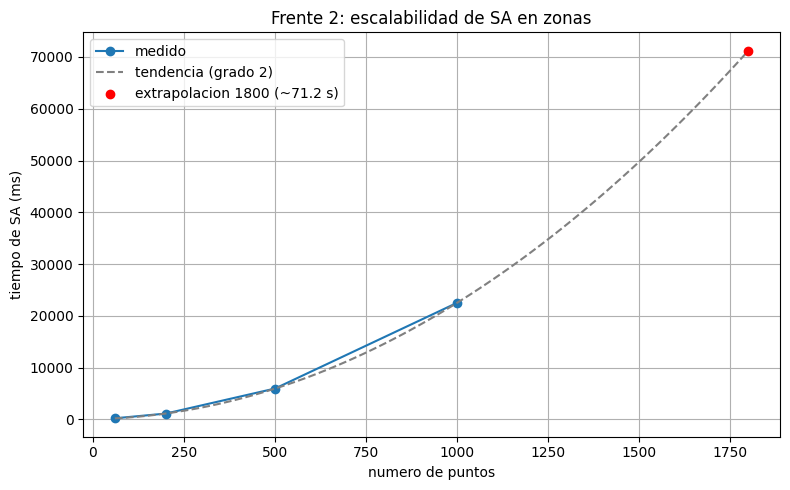

In [10]:
# max_iter moderado (150) para que el estudio termine en tiempo razonable:
# interesa medir la TENDENCIA del tiempo con n, no la calidad final de la solucion.
def estudio_escalabilidad_zonas(tamanos=(60, 200, 500, 1000), n_cuadrillas=4, max_iter_test=150): # Aqui se define la funcion para realizar el estudio de escalabilidad del algoritmo de Simulated Annealing en el problema de asignacion de zonas a cuadrillas, con diferentes tamaños de instancias y un numero moderado de iteraciones, para medir la tendencia del tiempo de ejecucion en funcion del numero de puntos
    filas = [] # Aqui se crea una lista vacia, que se utilizara para almacenar los resultados del estudio de escalabilidad, donde cada elemento de la lista sera una tupla con el numero de puntos y el tiempo de ejecucion del algoritmo en milisegundos
    for n in tamanos: # Aqui se define un bucle for que recorre los valores de la tupla tamanos, que representan el numero de puntos a evaluar en cada instancia del estudio de escalabilidad, y se utiliza para generar diferentes instancias del problema con distintos numeros de puntos
        red_n = generar_red_logistica(n_puntos=n, n_cuadrillas=n_cuadrillas) # Aqui se llama a la funcion generar_red_logistica para generar una red logistica con n puntos y n_cuadrillas cuadrillas, y se almacena en la variable red_n, que se utilizara para crear la instancia del problema de asignacion de zonas a cuadrillas
        dist_n = matriz_distancias(red_n) # Aqui se llama a la funcion matriz_distancias para calcular la matriz de distancias entre los puntos de la red generada anteriormente, y se almacena en la variable dist_n, que se utilizara para crear la instancia del problema de asignacion de zonas a cuadrillas
        prob = ProblemaZonas(red_n, dist_n, n_cuadrillas) # Aqui se crea una instancia del problema de asignacion de zonas a cuadrillas, utilizando la clase definida anteriormente, con los parametros de la red generada anteriormente, la matriz de distancias calculada anteriormente y el numero de cuadrillas especificado
        random.seed(SEED); np.random.seed(SEED) # Aqui se establece la semilla para los generadores de numeros aleatorios de los modulos random y numpy, utilizando la constante SEED definida anteriormente, para asegurar que los resultados del estudio de escalabilidad sean reproducibles y consistentes en cada ejecucion
        t0 = time.perf_counter() # Aqui se inicia el contador de tiempo para medir el tiempo de ejecucion del algoritmo de Simulated Annealing en la instancia del problema creada anteriormente
        simulated_annealing(prob, T0=500, alpha=0.999, Tmin=0.1, max_iter=max_iter_test) # Aqui se ejecuta el algoritmo de Simulated Annealing para encontrar una asignacion de zonas a cuadrillas que minimice el costo total, utilizando la instancia del problema creada anteriormente y los parametros del algoritmo (T0=500, alpha=0.999, Tmin=0.1, max_iter=max_iter_test), y se descarta la asignacion encontrada ya que solo nos interesa medir el tiempo de ejecucion
        filas.append((n, (time.perf_counter() - t0) * 1000)) # Aqui se calcula el tiempo de ejecucion del algoritmo en milisegundos, restando el tiempo inicial del tiempo actual y multiplicando por 1000 para convertir a milisegundos, y se agrega una tupla con el numero de puntos n y el tiempo de ejecucion calculado a la lista filas
    return pd.DataFrame(filas, columns=["n puntos", "tiempo (ms)"]), max_iter_test # Aqui se crea un DataFrame de pandas a partir de la lista filas, que contiene la informacion de todas las instancias evaluadas en el estudio de escalabilidad, con las columnas "n puntos" y "tiempo (ms)", y se retorna junto con el numero de iteraciones max_iter_test utilizado en el estudio


tabla_escala, MAXIT_ESCALA = estudio_escalabilidad_zonas() # Aqui se llama a la funcion estudio_escalabilidad_zonas para realizar el estudio de escalabilidad del algoritmo de Simulated Annealing en el problema de asignacion de zonas a cuadrillas, y se obtienen el DataFrame con los resultados del estudio y el numero de iteraciones max_iter_test utilizado en el estudio, que se almacenan en las variables tabla_escala y MAXIT_ESCALA respectivamente
print("BLOQUE C(2) - Escalabilidad de SA en zonas (max_iter =", MAXIT_ESCALA, ")") # Aqui se imprime un mensaje indicando que se ejecuto el estudio de escalabilidad del algoritmo de Simulated Annealing en el problema de asignacion de zonas a cuadrillas, y se muestra el numero de iteraciones max_iter_test utilizado en el estudio
print(tabla_escala.to_string(index=False)) # Aqui se imprime el DataFrame tabla_escala, que contiene la informacion de todas las instancias evaluadas en el estudio de escalabilidad, sin mostrar los indices de las filas, para mostrar los resultados del estudio de manera clara y legible
 
coef = np.polyfit(tabla_escala["n puntos"], tabla_escala["tiempo (ms)"], 2) # Aqui se utiliza la funcion polyfit de numpy para ajustar un polinomio de grado 2 a los datos del DataFrame tabla_escala, utilizando las columnas "n puntos" y "tiempo (ms)" como variables independientes y dependientes respectivamente, y se obtienen los coeficientes del polinomio ajustado, que se almacenan en la variable coef
pred_1800 = float(np.polyval(coef, 1800)) # Aqui se utiliza la funcion polyval de numpy para evaluar el polinomio ajustado en el valor 1800, utilizando los coeficientes del polinomio almacenados en la variable coef, y se obtiene la prediccion del tiempo de ejecucion del algoritmo de Simulated Annealing para una instancia con 1800 puntos, que se almacena en la variable pred_1800
factor_calidad = 40000 / MAXIT_ESCALA # Aqui se calcula el factor de calidad, que es el cociente entre el numero de iteraciones max_iter utilizado en la ejecucion de produccion (40000) y el numero de iteraciones max_iter utilizado en el estudio de escalabilidad (MAXIT_ESCALA), y se almacena en la variable factor_calidad, que se utilizara para estimar el tiempo de ejecucion del algoritmo para una instancia con 1800 puntos en condiciones de produccion
print(f"\nTendencia (grado 2): t(ms) ~ {coef[0]:.3e}*n^2 + {coef[1]:.3e}*n + {coef[2]:.1f}") # Aqui se imprime un mensaje indicando la tendencia del tiempo de ejecucion del algoritmo de Simulated Annealing en funcion del numero de puntos, utilizando los coeficientes del polinomio ajustado almacenados en la variable coef, y se muestra la ecuacion del polinomio en notacion cientifica con 3 decimales para los coeficientes y 1 decimal para el termino independiente
print(f"Extrapolacion a 1800 puntos: {pred_1800:.0f} ms ~ {pred_1800/1000:.1f} s (con max_iter={MAXIT_ESCALA})") # Aqui se imprime un mensaje indicando la extrapolacion del tiempo de ejecucion del algoritmo de Simulated Annealing para una instancia con 1800 puntos, utilizando la prediccion almacenada en la variable pred_1800, y se muestra el tiempo en milisegundos y en segundos, junto con el numero de iteraciones max_iter utilizado en el estudio de escalabilidad
print(f"Con max_iter=40000 (calidad de produccion) escalaria ~x{factor_calidad:.0f} " # Aqui se imprime un mensaje indicando la estimacion del tiempo de ejecucion del algoritmo de Simulated Annealing para una instancia con 1800 puntos en condiciones de produccion, utilizando el factor de calidad almacenado en la variable factor_calidad, y se muestra el tiempo estimado en minutos
      f"-> ~{pred_1800/1000*factor_calidad/60:.0f} min para 1800 puntos") # Aqui se calcula el tiempo estimado en minutos para una instancia con 1800 puntos en condiciones de produccion, utilizando la prediccion almacenada en la variable pred_1800, el factor de calidad almacenado en la variable factor_calidad y la conversion de milisegundos a minutos, y se muestra el resultado en un mensaje

fig_esc, ax_esc = plt.subplots(figsize=(8, 5)) # Aqui se crea una figura y un eje para graficar los resultados del estudio de escalabilidad del algoritmo de Simulated Annealing en el problema de asignacion de zonas a cuadrillas, utilizando la funcion subplots de matplotlib, y se especifica el tamaño de la figura en pulgadas (8x5)
ax_esc.plot(tabla_escala["n puntos"], tabla_escala["tiempo (ms)"], "o-", label="medido") # Aqui se grafica la curva de tiempo de ejecucion del algoritmo de Simulated Annealing en funcion del numero de puntos, utilizando los datos del DataFrame tabla_escala, y se especifica el estilo de la curva como puntos conectados por lineas ("o-") y se agrega una etiqueta para la leyenda ("medido")
xs = np.linspace(60, 1800, 100) # Aqui se crea un arreglo de 100 valores equiespaciados entre 60 y 1800, utilizando la funcion linspace de numpy, que se utilizara para evaluar el polinomio ajustado y graficar la tendencia del tiempo de ejecucion del algoritmo de Simulated Annealing en funcion del numero de puntos
ax_esc.plot(xs, np.polyval(coef, xs), "--", color="gray", label="tendencia (grado 2)") # Aqui se grafica la curva de tendencia del tiempo de ejecucion del algoritmo de Simulated Annealing en funcion del numero de puntos, utilizando los valores del arreglo xs y evaluando el polinomio ajustado con la funcion polyval de numpy, y se especifica el estilo de la curva como lineas discontinuas ("--"), el color como gris y se agrega una etiqueta para la leyenda ("tendencia (grado 2)")
ax_esc.scatter([1800], [pred_1800], color="red", zorder=5, # Aqui se grafica un punto rojo en la coordenada (1800, pred_1800) para indicar la extrapolacion del tiempo de ejecucion del algoritmo de Simulated Annealing para una instancia con 1800 puntos, utilizando la funcion scatter de matplotlib, y se especifica el color como rojo y el orden de dibujo como 5 para que se muestre por encima de las curvas
               label=f"extrapolacion 1800 (~{pred_1800/1000:.1f} s)") # Aqui se agrega una etiqueta para la leyenda del punto rojo, indicando que representa la extrapolacion del tiempo de ejecucion del algoritmo de Simulated Annealing para una instancia con 1800 puntos, y se muestra el tiempo estimado en segundos
ax_esc.set_xlabel("numero de puntos"); ax_esc.set_ylabel("tiempo de SA (ms)") # Aqui se establecen las etiquetas de los ejes x, y del grafico, indicando que el eje x representa el numero de puntos y el eje y representa el tiempo de ejecucion del algoritmo de Simulated Annealing en milisegundos
ax_esc.set_title("Frente 2: escalabilidad de SA en zonas") # Aqui se establece el titulo del grafico, indicando que representa el estudio de escalabilidad del algoritmo de Simulated Annealing en el problema de asignacion de zonas a cuadrillas
ax_esc.legend(); plt.tight_layout(); plt.show() # Aqui se muestra la leyenda del grafico, se ajusta el diseño de la figura para que no se superpongan los elementos y se muestra la figura en pantalla

Interpretación: con `max_iter` moderado, una sola pasada de SA para 1800 puntos toma del orden de pocos minutos (ver extrapolación). Como el costo por evaluación crece de forma **cuadrática**, una corrida con la calidad de producción (`max_iter` alto, como el usado en el Frente 2) escalaría a **decenas de minutos**, lo que hace que 1800 puntos **no sea práctico en tiempo real** con esta implementación pura en Python. Sí es factible como **proceso offline** o reduciéndolo con optimizaciones directas: evaluación **incremental** del costo (recalcular solo la zona modificada en cada vecino en lugar de toda la red), vectorización con NumPy o partición previa por sectores geográficos.

---
## Frente 3 — Reabastecimiento diario bajo incertidumbre

### 4.1 Formulación del MDP
Estados (inventario), acciones (cantidad a enviar), transición estocástica (demanda) y recompensa (ingreso − merma − agotado).

In [11]:
class MDPReabastecimiento: # Aqui se define un MDP para el problema de reabastecimiento de inventario en un punto de venta, con los parametros de demanda, inventario maximo, precio de venta, costo unitario, costo por merma, costo por agotado y factor de descuento
    def __init__(self, demanda_punto, inv_max=20, precio=5.0, costo_unit=2.0, # Aqui se inicializa los atributos de la instancia con los parametros de demanda, inventario maximo, precio de venta, costo unitario, costo por merma, costo por agotado y factor de descuento
                 costo_merma=3.0, costo_agotado=4.0, gamma=0.95): # Aqui se definen los parametros que son la serie de demanda del punto de venta, el inventario maximo, el precio de venta, el costo unitario, el costo por merma, el costo por agotado y el factor de descuento
        self.inv_max = inv_max # Aqui se asigna el valor del inventario maximo al atributo inv_max de la instancia, que representa la cantidad maxima de unidades que se pueden almacenar en el punto de venta
        self.precio = precio # Aqui se asigna el valor del precio de venta al atributo precio de la instancia, que representa el precio al que se venden las unidades en el punto de venta
        self.costo_unit = costo_unit # Aqui se asigna el valor del costo unitario al atributo costo_unit de la instancia, que representa el costo de adquirir una unidad para reabastecer el inventario del punto de venta
        self.costo_merma = costo_merma # Aqui se asigna el valor del costo por merma al atributo costo_merma de la instancia, que representa el costo asociado a las unidades excedentes
        self.costo_agotado = costo_agotado # Aqui se asigna el valor del costo por agotado al atributo costo_agotado de la instancia, que representa el costo asociado a las unidades no disponibles
        self.gamma = gamma # Aqui se asigna el valor del factor de descuento al atributo gamma de la instancia, que representa la tasa de descuento para futuras recompensas
        self.S = list(range(inv_max + 1)) # Aqui se crea una lista de estados posibles del inventario, que van desde 0 hasta el inventario maximo, y se asigna al atributo S de la instancia, que representa los posibles niveles de inventario en el punto de venta
        self.A = list(range(inv_max + 1)) # Aqui se crea una lista de acciones posibles, que van desde 0 hasta el inventario maximo, y se asigna al atributo A de la instancia, que representa las posibles cantidades de reabastecimiento
        self.dist_demanda = self._estimar_demanda(demanda_punto) # Aqui se llama al metodo _estimar_demanda para estimar la distribucion de probabilidad de la demanda del punto de venta, utilizando la serie de demanda proporcionada como parametro, y se asigna al atributo dist_demanda de la instancia, que representa la distribucion de probabilidad de la demanda en el punto de venta

    def _estimar_demanda(self, serie): # Aqui se define el metodo _estimar_demanda, que estima la distribucion de probabilidad de la demanda del punto de venta a partir de la serie de demanda proporcionada como parametro
        # Escala la demanda a "lotes" para que el inventario maximo cubra ~el pico,
        # generando un verdadero compromiso entre merma (exceso) y agotado (defecto).
        serie = np.asarray(serie, dtype=float) # Aqui se convierte la serie de demanda proporcionada como parametro en un arreglo de numpy de tipo float, para facilitar el procesamiento y los calculos posteriores
        escala = self.inv_max / (serie.max() + 1e-9) # Aqui se calcula un factor de escala para ajustar la demanda a "lotes", dividiendo el inventario maximo por el valor maximo de la serie de demanda mas un valor muy pequeño (1e-9) para evitar la division por cero, y se asigna a la variable escala
        lotes = np.clip(np.round(serie * escala), 0, self.inv_max).astype(int) # Aqui se ajusta la serie de demanda a "lotes" multiplicando cada valor de la serie por el factor de escala calculado anteriormente, redondeando los valores resultantes, y luego se limita el rango de los valores a un minimo de 0 y un maximo del inventario maximo utilizando la funcion clip de numpy, y finalmente se convierte el arreglo resultante a tipo int, y se asigna a la variable lotes
        valores, conteos = np.unique(lotes, return_counts=True) # Aqui se utiliza la funcion unique de numpy para obtener los valores unicos de la serie de lotes ajustada y sus respectivas frecuencias de ocurrencia, y se asignan a las variables valores y conteos respectivamente
        probs = conteos / conteos.sum() # Aqui se calcula la distribucion de probabilidad de la demanda dividiendo las frecuencias de ocurrencia de cada valor unico por la suma total de las frecuencias, y se asigna a la variable probs
        return dict(zip(valores.tolist(), probs.tolist())) # Aqui se crea un diccionario que mapea cada valor unico de la serie de lotes ajustada a su respectiva probabilidad de ocurrencia, utilizando la funcion zip para combinar las listas de valores y probabilidades, y luego se convierte a un diccionario utilizando la funcion dict, y se retorna como resultado del metodo _estimar_demanda

    def recompensa(self, s, a, d): # Aqui se define el metodo recompensa, que calcula la recompensa obtenida en un periodo de tiempo dado el estado actual del inventario s, la accion tomada a y la demanda observada d
        disponible = min(s + a, self.inv_max) # Aqui se calcula la cantidad disponible de unidades en el inventario despues de tomar la accion a, sumando el estado actual del inventario s y la accion tomada a, y limitando el resultado al inventario maximo utilizando la funcion min, y se asigna a la variable disponible
        vendido = min(disponible, d) # Aqui se calcula la cantidad de unidades vendidas, tomando el minimo entre la cantidad disponible y la demanda observada, y se asigna a la variable vendido
        sobrante = disponible - vendido # Aqui se calcula la cantidad de unidades excedentes, restando la cantidad vendida de la cantidad disponible, y se asigna a la variable sobrante
        faltante = max(d - disponible, 0) # Aqui se calcula la cantidad de unidades faltantes, tomando el maximo entre la demanda observada menos la cantidad disponible y cero, y se asigna a la variable faltante
        ingreso = self.precio * vendido # Aqui se calcula el ingreso total por ventas, multiplicando el precio de venta por la cantidad vendida, y se asigna a la variable ingreso
        costo_compra = self.costo_unit * a # Aqui se calcula el costo total de compra, multiplicando el costo unitario por la cantidad comprada, y se asigna a la variable costo_compra
        penal_merma = self.costo_merma * sobrante # Aqui se calcula la penalizacion por merma, multiplicando el costo por merma por la cantidad de unidades excedentes, y se asigna a la variable penal_merma
        penal_agotado = self.costo_agotado * faltante # Aqui se calcula la penalizacion por agotado, multiplicando el costo por agotado por la cantidad de unidades faltantes, y se asigna a la variable penal_agotado
        return ingreso - costo_compra - penal_merma - penal_agotado # Aqui se calcula la recompensa neta obtenida en el periodo de tiempo, restando el costo total de compra, la penalizacion por merma y la penalizacion por agotado del ingreso total por ventas, y se retorna como resultado del metodo recompensa

    def transicion(self, s, a): # Aqui se define el metodo transicion, que calcula la distribucion de probabilidad de los estados futuros del inventario dado el estado actual s y la accion tomada a
        disponible = min(s + a, self.inv_max) # Aqui se calcula la cantidad disponible de unidades en el inventario despues de tomar la accion a, sumando el estado actual del inventario s y la accion tomada a, y limitando el resultado al inventario maximo utilizando la funcion min, y se asigna a la variable disponible
        resultados = {} # Aqui se crea un diccionario vacio resultados, que se utilizara para almacenar la distribucion de probabilidad de los estados futuros del inventario, donde las claves seran los estados futuros y los valores seran tuplas con la probabilidad de ocurrencia y la recompensa ponderada correspondiente
        for d, p in self.dist_demanda.items(): # Aqui se recorre la distribucion de probabilidad de la demanda, utilizando el metodo items() para obtener tanto la demanda d como su probabilidad p, y se utiliza para calcular los estados futuros del inventario y sus respectivas recompensas
            sobrante = max(disponible - d, 0) # Aqui se calcula la cantidad de unidades excedentes, tomando el maximo entre la cantidad disponible menos la demanda observada y cero, y se asigna a la variable sobrante
            s_sig = int(min(sobrante, self.inv_max)) # Aqui se calcula el estado futuro del inventario, tomando el minimo entre la cantidad de unidades excedentes y el inventario maximo, y se convierte a entero, y se asigna a la variable s_sig
            r = self.recompensa(s, a, d) # Aqui se calcula la recompensa obtenida en el periodo de tiempo, utilizando el metodo recompensa con los parametros s, a y d, y se asigna a la variable r
            if s_sig not in resultados: # Aqui se verifica si el estado futuro s_sig no esta presente en el diccionario resultados, y si es asi, se inicializa con una lista de dos elementos [0.0, 0.0] para almacenar la probabilidad acumulada y la recompensa ponderada acumulada correspondiente a ese estado futuro
                resultados[s_sig] = [0.0, 0.0] # Aqui se inicializa el estado futuro s_sig en el diccionario resultados con una lista de dos elementos [0.0, 0.0], que representaran la probabilidad acumulada y la recompensa ponderada acumulada correspondiente a ese estado futuro
            resultados[s_sig][0] += p # Aqui se acumula la probabilidad de ocurrencia p del estado futuro s_sig en el primer elemento de la lista correspondiente en el diccionario resultados, sumando p al valor actual
            resultados[s_sig][1] += p * r # Aqui se acumula la recompensa ponderada correspondiente al estado futuro s_sig en el segundo elemento de la lista correspondiente en el diccionario resultados, sumando p * r al valor actual, donde r es la recompensa obtenida en el periodo de tiempo
        salida = {} # Aqui se crea un diccionario vacio salida, que se utilizara para almacenar la distribucion de probabilidad de los estados futuros del inventario junto con la recompensa ponderada correspondiente, donde las claves seran los estados futuros y los valores seran tuplas con la probabilidad de ocurrencia y la recompensa ponderada correspondiente
        for s_sig, (prob, r_pond) in resultados.items(): # Aqui se recorre el diccionario resultados, utilizando el metodo items() para obtener tanto el estado futuro s_sig como la tupla (prob, r_pond) que contiene la probabilidad acumulada y la recompensa ponderada acumulada correspondiente a ese estado futuro, y se utiliza para calcular la recompensa ponderada promedio para cada estado futuro
            salida[s_sig] = (prob, r_pond / prob if prob > 0 else 0.0) # Aqui se calcula la recompensa ponderada promedio para cada estado futuro s_sig, dividiendo la recompensa ponderada acumulada r_pond entre la probabilidad acumulada prob, y se almacena en el diccionario salida como una tupla (prob, recompensa_ponderada_promedio), donde si la probabilidad acumulada es cero, se asigna un valor de 0.0 para evitar la division por cero
        return salida # Aqui se retorna el diccionario salida, que contiene la distribucion de probabilidad de los estados futuros del inventario junto con la recompensa ponderada promedio correspondiente para cada estado futuro, como resultado del metodo transicion


### 4.2 Policy Iteration
Evaluación de la política (`policy_evaluation`) y mejora (`policy_improvement`) hasta converger a la política óptima.

In [12]:
def policy_evaluation(politica, mdp, epsilon=1e-4): # Aqui se define la funcion policy_evaluation, que evalua una politica dada en el MDP utilizando el metodo de iteracion de valor, con un criterio de convergencia basado en un umbral epsilon
    V = {s: 0.0 for s in mdp.S} # Aqui se crea un diccionario V que representa la funcion de valor para cada estado del MDP, inicializando todos los valores a 0.0, utilizando una comprension de diccionario que recorre todos los estados s en mdp.S y asigna 0.0 como valor inicial para cada estado
    while True: # Aqui se inicia un bucle while que se ejecutara indefinidamente hasta que se cumpla el criterio de convergencia basado en el umbral epsilon, para evaluar la politica dada en el MDP
        delta = 0 # Aqui se inicializa la variable delta a 0, que se utilizara para almacenar el cambio maximo en la funcion de valor V durante una iteracion completa sobre todos los estados del MDP, y se utilizara para determinar si se ha alcanzado la convergencia
        for s in mdp.S: # Aqui se inicia un bucle for que recorre todos los estados s en mdp.S, para actualizar la funcion de valor V para cada estado segun la politica dada y las transiciones del MDP
            v_anterior = V[s] # Aqui se almacena el valor anterior de la funcion de valor V para el estado s en la variable v_anterior, antes de actualizarlo segun la politica dada y las transiciones del MDP
            a = politica[s] # Aqui se obtiene la accion a correspondiente a la politica dada para el estado s, utilizando el diccionario politica que mapea cada estado a una accion, y se asigna a la variable a
            trans = mdp.transicion(s, a) # Aqui se obtiene la distribucion de probabilidad de los estados futuros y las recompensas correspondientes para el estado s y la accion a, utilizando el metodo transicion del MDP, y se asign
            V[s] = sum(prob * (r + mdp.gamma * V[s_sig]) # Aqui se actualiza el valor de la funcion de valor V para el estado s, calculando la suma ponderada de las recompensas y los valores futuros de los estados alcanzables s_sig, multiplicando la probabilidad prob de cada transicion por la suma de la recompensa r y el valor futuro descontado mdp.gamma * V[s_sig], y se asigna el resultado a V[s]
                       for s_sig, (prob, r) in trans.items()) # Aqui se utiliza una comprension de generador que recorre todos los estados futuros s_sig y sus respectivas probabilidades prob y recompensas r en la
            delta = max(delta, abs(v_anterior - V[s])) # Aqui se actualiza la variable delta con el cambio maximo en la funcion de valor V durante la iteracion completa sobre todos los estados del MDP, calculando el valor absoluto de la diferencia entre el valor anterior v_anterior y el nuevo valor V[s] para cada estado s, y tomando el maximo entre el valor actual de delta y la diferencia calculada
        if delta < epsilon: # Aqui se verifica si el cambio maximo en la funcion de valor V durante la iteracion completa sobre todos los estados del MDP es menor que el umbral epsilon, lo que indica que se ha alcanzado la convergencia y se puede salir del bucle while
            break # Aqui se rompe el bucle while si se ha alcanzado la convergencia, saliendo de la funcion policy_evaluation
    return V # Aqui se retorna el diccionario V que representa la funcion de valor evaluada para la politica dada en el MDP, como resultado de la funcion policy_evaluation


def policy_improvement(V, politica_actual, mdp): # Aqui se define la funcion policy_improvement, que mejora una politica dada en el MDP utilizando la funcion de valor V evaluada previamente, y devuelve una nueva politica mejorada y un indicador de estabilidad
    politica_nueva = {} # Aqui se crea un diccionario vacio politica_nueva, que se utilizara para almacenar la nueva politica mejorada, donde las claves seran los estados del MDP y los valores seran las acciones correspondientes a la nueva politica
    politica_estable = True # Aqui se inicializa la variable politica_estable a True, que se utilizara como indicador de estabilidad para determinar si la nueva politica mejorada es igual a la politica actual, y se actualizara a False si se encuentra alguna accion diferente entre ambas politicas
    for s in mdp.S: # Aqui se inicia un bucle for que recorre todos los estados s en mdp.S, para mejorar la politica actual utilizando la funcion de valor V evaluada previamente y las transiciones del MDP
        q_valores = {}
        for a in mdp.A:
            trans = mdp.transicion(s, a)
            q_valores[a] = sum(prob * (r + mdp.gamma * V[s_sig])
                               for s_sig, (prob, r) in trans.items())
        mejor_accion = max(q_valores, key=q_valores.get)
        politica_nueva[s] = mejor_accion
        if mejor_accion != politica_actual[s]:
            politica_estable = False
    return politica_nueva, politica_estable


def policy_iteration(mdp, epsilon=1e-4):
    politica = {s: random.choice(mdp.A) for s in mdp.S}
    ciclos = 0
    while True:
        ciclos += 1
        V = policy_evaluation(politica, mdp, epsilon)
        politica, estable = policy_improvement(V, politica, mdp)
        if estable:
            break
    return politica, V, ciclos


def value_iteration(mdp, epsilon=1e-4):
    # Iteracion de valor clasica: itera V hasta que el cambio maximo sea < epsilon
    V = {s: 0.0 for s in mdp.S}
    n_iteraciones = 0
    while True:
        n_iteraciones += 1
        delta = 0
        for s in mdp.S:
            v_anterior = V[s]
            # V[s] = max_a sum_s' P(s'|s,a) * (r + gamma * V[s'])
            mejores = []
            for a in mdp.A:
                trans = mdp.transicion(s, a)
                mejores.append(sum(prob * (r + mdp.gamma * V[s_sig])
                                   for s_sig, (prob, r) in trans.items()))
            V[s] = max(mejores)
            delta = max(delta, abs(v_anterior - V[s]))
        if delta < epsilon:
            break
    # Extraccion de la politica optima: argmax_a sobre el V convergido
    politica = {}
    for s in mdp.S:
        q_valores = {}
        for a in mdp.A:
            trans = mdp.transicion(s, a)
            q_valores[a] = sum(prob * (r + mdp.gamma * V[s_sig])
                               for s_sig, (prob, r) in trans.items())
        politica[s] = max(q_valores, key=q_valores.get)
    return politica, V, n_iteraciones


### 4.3 Experimento: política óptima vs. heurística ingenua
Simulación sobre datos de prueba comparando rentabilidad, nivel de servicio, agotados y merma.

In [13]:
def escalar_a_lotes(serie, ref, inv_max):
    escala = inv_max / (np.asarray(ref, dtype=float).max() + 1e-9)
    return np.clip(np.round(np.asarray(serie, dtype=float) * escala), 0, inv_max).astype(int)


def simular_politica(mdp, politica, demanda_serie_lotes, s_inicial=0):
    s = s_inicial
    registro = {"ingreso": 0.0, "vendido": 0, "merma": 0, "agotado": 0, "demanda": 0}
    for d in demanda_serie_lotes:
        d = int(min(d, mdp.inv_max))
        a = politica[s]
        disponible = min(s + a, mdp.inv_max)
        vendido = min(disponible, d)
        sobrante = disponible - vendido
        faltante = max(d - disponible, 0)
        registro["ingreso"] += mdp.recompensa(s, a, d)
        registro["vendido"] += vendido
        registro["merma"] += sobrante
        registro["agotado"] += faltante
        registro["demanda"] += d
        s = int(min(sobrante, mdp.inv_max))
    dem = max(registro["demanda"], 1)
    registro["nivel_servicio"] = registro["vendido"] / dem
    registro["tasa_agotado"] = registro["agotado"] / dem
    registro["tasa_merma"] = registro["merma"] / max(registro["vendido"] + registro["merma"], 1)
    return registro


def politica_heuristica(mdp):
    # Heuristica ingenua: pedir la demanda media esperada sin considerar
    # el inventario disponible ni la asimetria entre costo de merma y de agotado.
    demanda_media = sum(d * p for d, p in mdp.dist_demanda.items())
    pedido_fijo = int(round(demanda_media))
    return {s: pedido_fijo for s in mdp.S}


def experimento_frente3(demanda, punto=0):
    serie = demanda[:, punto]
    train, test = serie[:120], serie[120:]
    mdp = MDPReabastecimiento(train)

    pi_opt, V, ciclos = policy_iteration(mdp)
    pi_heur = politica_heuristica(mdp)

    test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
    r_opt = simular_politica(mdp, pi_opt, test_lotes)
    r_heur = simular_politica(mdp, pi_heur, test_lotes)

    tabla = pd.DataFrame([
        ("Policy Iteration (optima)", r_opt["ingreso"], r_opt["nivel_servicio"], r_opt["tasa_agotado"], r_opt["tasa_merma"]),
        ("Heuristica (nivel fijo)", r_heur["ingreso"], r_heur["nivel_servicio"], r_heur["tasa_agotado"], r_heur["tasa_merma"]),
    ], columns=["Politica", "Rentabilidad", "Nivel servicio", "Tasa agotados", "Tasa merma"])
    return tabla, pi_opt, V, ciclos, mdp


tabla_f3, pi_opt, V_f3, ciclos_f3, mdp_f3 = experimento_frente3(DEMANDA)
print("FRENTE 3 - Reabastecimiento diario bajo incertidumbre")
print(f"Policy Iteration convergio en {ciclos_f3} ciclos\n")
print(tabla_f3.to_string(index=False))
print("\nPolitica optima (inventario -> cuanto pedir):")
print({s: pi_opt[s] for s in mdp_f3.S})


FRENTE 3 - Reabastecimiento diario bajo incertidumbre
Policy Iteration convergio en 3 ciclos

                 Politica  Rentabilidad  Nivel servicio  Tasa agotados  Tasa merma
Policy Iteration (optima)        1068.0         0.89913        0.10087    0.138333
  Heuristica (nivel fijo)         883.0         0.93913        0.06087    0.269283

Politica optima (inventario -> cuanto pedir):
{0: 10, 1: 9, 2: 8, 3: 7, 4: 6, 5: 5, 6: 4, 7: 3, 8: 2, 9: 1, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0}


---
## Frente 4 — Política de inventario a largo plazo

### 5.1 Sensibilidad al descuento y generalización
Análisis de la política ante distintos valores de gamma y distintos perfiles de punto de venta.

In [14]:
def sensibilidad_gamma(demanda, punto=0, gammas=(0.5, 0.8, 0.9, 0.95, 0.99)):
    train = demanda[:120, punto]
    test = demanda[120:, punto]
    filas = []
    for g in gammas:
        mdp = MDPReabastecimiento(train, gamma=g)
        pi, V, ciclos = policy_iteration(mdp)
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
        r = simular_politica(mdp, pi, test_lotes)
        pedido_medio = np.mean([pi[s] for s in mdp.S])
        filas.append((g, pedido_medio, r["nivel_servicio"], r["tasa_merma"], r["ingreso"]))
    return pd.DataFrame(filas, columns=["gamma", "Pedido medio", "Nivel servicio", "Tasa merma", "Rentabilidad"])


tabla_gamma = sensibilidad_gamma(DEMANDA)

print("FRENTE 4 - Politica de largo plazo")
print("\nSensibilidad al factor de descuento (gamma):")
print(tabla_gamma.to_string(index=False))


FRENTE 4 - Politica de largo plazo

Sensibilidad al factor de descuento (gamma):
 gamma  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
  0.50      2.619048         0.89913    0.138333        1068.0
  0.80      2.619048         0.89913    0.138333        1068.0
  0.90      2.619048         0.89913    0.138333        1068.0
  0.95      2.619048         0.89913    0.138333        1068.0
  0.99      2.619048         0.89913    0.138333        1068.0


### 5.2 Extensión — Inventario con vida útil

En el modelo original (`MDPReabastecimiento`) el sobrante pasa íntegro al día siguiente pero casi siempre se consume, de modo que el problema se comporta como **de una sola etapa** y el factor de descuento $\gamma$ no influye (de ahí la sensibilidad plana del Frente 4). Ese comportamiento era **correcto**, pero correspondía a un inventario **sin memoria** entre días.

Aquí se define `MDPReabastecimientoVidaUtil` (**sin modificar** la clase original), donde el inventario es **perecedero con vida útil de 2 días**: el estado representa el stock que **vence hoy**, la venta es FIFO (primero lo más viejo), lo viejo no vendido **caduca** (merma) y lo fresco no vendido se convierte en el stock que vencerá al día siguiente. Esa memoria entre etapas hace que $\gamma$ **sí** afecte la política.

In [15]:
class MDPReabastecimientoVidaUtil:
    """MDP de reabastecimiento con inventario PERECEDERO (vida util 2 dias).

    Estado s = unidades en stock que VENCEN HOY (lo que sobro fresco ayer).
    Accion a = unidades frescas pedidas hoy (con 2 dias de vida util).
    Venta FIFO (primero lo mas viejo). Lo viejo no vendido CADUCA (merma);
    lo fresco no vendido pasa a ser el stock que vencera al dia siguiente.
    Esta memoria entre dias es la que hace que gamma influya en la politica.
    """
    def __init__(self, demanda_punto, inv_max=20, precio=5.0, costo_unit=2.0,
                 costo_merma=3.0, costo_agotado=4.0, gamma=0.95):
        self.inv_max = inv_max
        self.precio = precio
        self.costo_unit = costo_unit
        self.costo_merma = costo_merma
        self.costo_agotado = costo_agotado
        self.gamma = gamma
        self.S = list(range(inv_max + 1))   # stock que vence hoy
        self.A = list(range(inv_max + 1))   # pedido fresco
        self.dist_demanda = self._estimar_demanda(demanda_punto)

    def _estimar_demanda(self, serie):
        serie = np.asarray(serie, dtype=float)
        escala = self.inv_max / (serie.max() + 1e-9)
        lotes = np.clip(np.round(serie * escala), 0, self.inv_max).astype(int)
        valores, conteos = np.unique(lotes, return_counts=True)
        probs = conteos / conteos.sum()
        return dict(zip(valores.tolist(), probs.tolist()))

    def _dinamica(self, s, a, d):
        viejo = int(min(s, self.inv_max))            # vence hoy
        fresco = int(min(a, self.inv_max))           # pedido de hoy
        disponible = viejo + fresco
        vendido = min(disponible, d)
        vendido_viejo = min(viejo, vendido)          # FIFO: primero lo viejo
        vendido_fresco = vendido - vendido_viejo
        caduca = viejo - vendido_viejo               # viejo no vendido -> merma
        sobra_fresco = fresco - vendido_fresco       # fresco no vendido -> vence manana
        faltante = max(d - disponible, 0)
        s_sig = int(min(sobra_fresco, self.inv_max))
        r = (self.precio * vendido - self.costo_unit * a
             - self.costo_merma * caduca - self.costo_agotado * faltante)
        return s_sig, r, vendido, caduca, faltante

    def recompensa(self, s, a, d):
        return self._dinamica(s, a, d)[1]

    def transicion(self, s, a):
        resultados = {}
        for d, p in self.dist_demanda.items():
            s_sig, r, *_ = self._dinamica(s, a, d)
            if s_sig not in resultados:
                resultados[s_sig] = [0.0, 0.0]
            resultados[s_sig][0] += p
            resultados[s_sig][1] += p * r
        return {ss: (pr, rp / pr if pr > 0 else 0.0)
                for ss, (pr, rp) in resultados.items()}


def simular_politica_vidautil(mdp, politica, demanda_serie_lotes, s_inicial=0):
    s = s_inicial
    reg = {"ingreso": 0.0, "vendido": 0, "merma": 0, "agotado": 0, "demanda": 0}
    for d in demanda_serie_lotes:
        d = int(min(d, mdp.inv_max))
        a = politica[s]
        s_sig, r, vendido, caduca, faltante = mdp._dinamica(s, a, d)
        reg["ingreso"] += r
        reg["vendido"] += vendido
        reg["merma"] += caduca
        reg["agotado"] += faltante
        reg["demanda"] += d
        s = s_sig
    dem = max(reg["demanda"], 1)
    reg["nivel_servicio"] = reg["vendido"] / dem
    reg["tasa_agotado"] = reg["agotado"] / dem
    reg["tasa_merma"] = reg["merma"] / max(reg["vendido"] + reg["merma"], 1)
    return reg


def sensibilidad_gamma_vidautil(demanda, punto=0, gammas=(0.5, 0.8, 0.9, 0.95, 0.99)):
    train = demanda[:120, punto]; test = demanda[120:, punto]
    filas = []; politicas = {}
    for gm in gammas:
        random.seed(SEED); np.random.seed(SEED)
        mdp = MDPReabastecimientoVidaUtil(train, gamma=gm)
        pi, V, ciclos = policy_iteration(mdp)
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
        r = simular_politica_vidautil(mdp, pi, test_lotes)
        politicas[gm] = tuple(pi[s] for s in mdp.S)
        filas.append((gm, round(float(np.mean([pi[s] for s in mdp.S])), 3),
                      round(r["nivel_servicio"], 4), round(r["tasa_merma"], 4),
                      round(r["ingreso"], 1)))
    tabla = pd.DataFrame(filas, columns=["gamma", "Pedido medio", "Nivel servicio",
                                         "Tasa merma", "Rentabilidad"])
    return tabla, politicas


tabla_gamma_vu, politicas_vu = sensibilidad_gamma_vidautil(DEMANDA)
n_distintas = len(set(politicas_vu.values()))
print("BLOQUE D - Sensibilidad a gamma con inventario de vida util (2 dias)")
print(tabla_gamma_vu.to_string(index=False))
print(f"\nPoliticas distintas entre los {len(politicas_vu)} valores de gamma: {n_distintas}")
print("=> con vida util, gamma SI cambia la politica y las metricas "
      "(a diferencia del modelo sin memoria del Frente 4 original).")

BLOQUE D - Sensibilidad a gamma con inventario de vida util (2 dias)
 gamma  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
  0.50         3.714          0.9600      0.0018        1553.0
  0.80         4.619          0.9757      0.0036        1609.0
  0.90         5.000          0.9774      0.0035        1616.0
  0.95         5.524          0.9861      0.0105        1629.0
  0.99         6.524          0.9861      0.0105        1629.0

Politicas distintas entre los 5 valores de gamma: 5
=> con vida util, gamma SI cambia la politica y las metricas (a diferencia del modelo sin memoria del Frente 4 original).


In [16]:
# Variante de la sensibilidad a gamma con vida util usando VALUE ITERATION
# (identica a sensibilidad_gamma_vidautil pero llamando value_iteration en vez de policy_iteration)
def sensibilidad_gamma_vidautil_vi(demanda, punto=0, gammas=(0.5, 0.8, 0.9, 0.95, 0.99)):
    train = demanda[:120, punto]; test = demanda[120:, punto]
    filas = []; politicas = {}
    for gm in gammas:
        random.seed(SEED); np.random.seed(SEED)
        mdp = MDPReabastecimientoVidaUtil(train, gamma=gm)
        pi, V, iters = value_iteration(mdp)               # <- unica diferencia vs la version PI
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
        r = simular_politica_vidautil(mdp, pi, test_lotes)
        politicas[gm] = tuple(pi[s] for s in mdp.S)
        filas.append((gm, round(float(np.mean([pi[s] for s in mdp.S])), 3),
                      round(r["nivel_servicio"], 4), round(r["tasa_merma"], 4),
                      round(r["ingreso"], 1)))
    tabla = pd.DataFrame(filas, columns=["gamma", "Pedido medio", "Nivel servicio",
                                         "Tasa merma", "Rentabilidad"])
    return tabla, politicas


tabla_gamma_vu_vi, politicas_vu_vi = sensibilidad_gamma_vidautil_vi(DEMANDA)
print("BLOQUE D (Value Iteration) - Sensibilidad a gamma con inventario de vida util")
print(tabla_gamma_vu_vi.to_string(index=False))

# Comparacion directa Policy Iteration vs Value Iteration sobre el MISMO MDP (gamma = 0.95)
random.seed(SEED); np.random.seed(SEED)
mdp_cmp = MDPReabastecimientoVidaUtil(DEMANDA[:120, 0], gamma=0.95)
random.seed(SEED); np.random.seed(SEED)
pi_pi, _, ciclos_pi = policy_iteration(mdp_cmp)            # politica via Policy Iteration
random.seed(SEED); np.random.seed(SEED)
pi_vi, _, iters_vi = value_iteration(mdp_cmp)              # politica via Value Iteration
coinciden = all(pi_pi[s] == pi_vi[s] for s in mdp_cmp.S)   # comparacion estado por estado
print("\nComparacion PI vs VI sobre el mismo MDP (gamma = 0.95):")
print(f"  Policy Iteration converge en {ciclos_pi} ciclos")
print(f"  Value Iteration  converge en {iters_vi} iteraciones")
print(f"  Ambos llegan a la MISMA politica optima: {coinciden}")
assert coinciden, "PI y VI deberian converger a la misma politica optima en este MDP"


BLOQUE D (Value Iteration) - Sensibilidad a gamma con inventario de vida util
 gamma  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
  0.50         3.714          0.9600      0.0018        1553.0
  0.80         4.619          0.9757      0.0036        1609.0
  0.90         5.000          0.9774      0.0035        1616.0
  0.95         5.524          0.9861      0.0105        1629.0
  0.99         6.524          0.9861      0.0105        1629.0



Comparacion PI vs VI sobre el mismo MDP (gamma = 0.95):
  Policy Iteration converge en 4 ciclos
  Value Iteration  converge en 137 iteraciones
  Ambos llegan a la MISMA politica optima: True


**Policy Iteration vs. Value Iteration.** Ambos algoritmos resuelven el mismo MDP y, por garantía teórica (el operador de Bellman es una contracción con punto fijo único cuando $\gamma < 1$), **convergen a la misma política óptima**. Por eso la sensibilidad a $\gamma$ es idéntica entre los dos métodos: la tabla generada con Value Iteration coincide con la de Policy Iteration. Lo que cambia es el **perfil de convergencia**: Value Iteration suele requerir más iteraciones, pero cada una es más barata (una sola pasada de actualización de $V$), mientras que Policy Iteration hace menos ciclos pero cada uno incluye una evaluación completa de política. El `assert` anterior verifica empíricamente que ambas políticas coinciden.

Con vida útil, la política y las métricas **sí cambian** al variar $\gamma$: a mayor $\gamma$ el modelo pondera más el desempeño futuro y mantiene un **buffer mayor** (pedido medio creciente y mejor nivel de servicio), mientras que con $\gamma$ bajo pide de forma más cortoplacista. Esto confirma que la sensibilidad plana del Frente 4 original **no era un error**, sino la consecuencia esperada de un inventario sin memoria entre días; al introducir la perecibilidad, el factor de descuento recupera su rol en la decisión.

### 5.3 Robustez de la política global del Frente 4

El documento de metodología define el Frente 4 como una política **global y robusta** que opera sobre distintos puntos de venta, categorías y condiciones cambiantes *sin requerir ajustes permanentes*. Para demostrarlo se clasifica cada punto de la red en uno de tres **perfiles**, se entrena **una sola política por perfil** (modelo con vida útil + Value Iteration) y se evalúa: (1) su desempeño aplicada a todos los puntos del perfil, (2) la degradación frente al óptimo individual y (3) su estabilidad bajo escenarios cambiantes.

In [17]:
# Robustez del Frente 4: UNA politica por PERFIL para toda la red.
# Reemplaza la antigua generalizacion_por_tipo (que entrenaba y evaluaba en un
# unico punto aleatorio y no evidenciaba robustez). Usa el modelo con vida util.
def construir_escenarios(demanda, punto=0):
    serie = demanda[:, punto].astype(float)
    n = len(serie)
    dias = np.arange(n)
    es_quincena = (dias % 15 == 0) | (dias % 30 == 0)
    umbral_alta = np.quantile(serie, 0.80)
    escenarios = {
        "ordinario": serie[(~es_quincena) & (serie < umbral_alta)],
        "alta_demanda": serie[(serie >= umbral_alta) | es_quincena],
        "perturbacion": serie * np.where(np.random.default_rng(SEED + 50).random(n) < 0.15, 1.5, 1.0),
    }
    dificultad = {
        "ordinario": "baja",
        "alta_demanda": "media",
        "perturbacion": "alta",
    }
    resumen = pd.DataFrame([
        (k, dificultad[k], len(v), round(float(np.mean(v)), 1), round(float(np.std(v)), 1))
        for k, v in escenarios.items()
    ], columns=["Escenario", "Dificultad", "N dias", "Demanda media", "Desv. estandar"])
    return escenarios, resumen


PERFILES_F4 = {
    "alta_rotacion":      dict(precio=6.0, costo_agotado=5.0, costo_merma=2.0),
    "perecedero_critico": dict(precio=5.0, costo_agotado=3.0, costo_merma=4.0),
    "bajo_margen":        dict(precio=3.5, costo_agotado=2.0, costo_merma=2.5),
}


def robustez_politica_frente4(demanda, gamma=0.95, n_muestra_degradacion=5):
    n_puntos = demanda.shape[1]
    nombres = list(PERFILES_F4)
    rng = np.random.default_rng(SEED)

    # (1) Asignacion reproducible de un perfil a cada punto de la red
    perfil_de_punto = {p: nombres[int(rng.integers(0, len(nombres)))] for p in range(n_puntos)}
    puntos_por_perfil = {nom: [p for p in range(n_puntos) if perfil_de_punto[p] == nom]
                         for nom in nombres}
    print("Puntos por perfil:", {k: len(v) for k, v in puntos_por_perfil.items()})

    # (2) UNA sola politica por perfil, entrenada con la demanda MEDIA del perfil (dias 0:120)
    politicas_por_perfil = {}
    mdp_por_perfil = {}
    ref_por_perfil = {}
    for nom in nombres:
        pts = puntos_por_perfil[nom]
        train_medio = demanda[:120, pts].mean(axis=1)      # serie media de todos los puntos del perfil
        random.seed(SEED); np.random.seed(SEED)
        mdp = MDPReabastecimientoVidaUtil(train_medio, gamma=gamma, **PERFILES_F4[nom])
        pi, _, _ = value_iteration(mdp)                    # una politica por perfil (no por punto)
        politicas_por_perfil[nom] = pi
        mdp_por_perfil[nom] = mdp
        ref_por_perfil[nom] = train_medio

    # (3) Robustez: aplicar la politica del perfil a TODOS sus puntos (sin recalcular)
    filas_perfil = []
    for nom in nombres:
        mdp = mdp_por_perfil[nom]; pi = politicas_por_perfil[nom]; ref = ref_por_perfil[nom]
        ns, tm, rent = [], [], []
        for p in puntos_por_perfil[nom]:
            test_lotes = escalar_a_lotes(demanda[120:, p], ref, mdp.inv_max)
            r = simular_politica_vidautil(mdp, pi, test_lotes)
            ns.append(r["nivel_servicio"]); tm.append(r["tasa_merma"]); rent.append(r["ingreso"])
        filas_perfil.append((nom, len(puntos_por_perfil[nom]),
                             round(float(np.mean(ns)), 4), round(float(np.std(ns)), 4),
                             round(float(np.mean(tm)), 4), round(float(np.std(tm)), 4),
                             round(float(np.mean(rent)), 1), round(float(np.std(rent)), 1)))
    tabla_robustez_perfil = pd.DataFrame(filas_perfil, columns=[
        "Perfil", "N puntos", "Nivel serv. media", "Nivel serv. std",
        "Tasa merma media", "Tasa merma std", "Rentab. media", "Rentab. std"])

    # (4) Degradacion vs OPTIMO INDIVIDUAL (muestra de puntos por perfil, sobre el MISMO modelo)
    degradaciones = []
    for nom in nombres:
        for p in puntos_por_perfil[nom][:n_muestra_degradacion]:
            train_p = demanda[:120, p]
            random.seed(SEED); np.random.seed(SEED)
            mdp_p = MDPReabastecimientoVidaUtil(train_p, gamma=gamma, **PERFILES_F4[nom])
            pi_p, _, _ = value_iteration(mdp_p)            # politica optima individual del punto
            test_lotes_p = escalar_a_lotes(demanda[120:, p], train_p, mdp_p.inv_max)
            r_opt = simular_politica_vidautil(mdp_p, pi_p, test_lotes_p)                              # optimo del punto
            r_perfil = simular_politica_vidautil(mdp_p, politicas_por_perfil[nom], test_lotes_p)     # politica del perfil
            if r_opt["ingreso"] > 0:
                degradaciones.append((r_opt["ingreso"] - r_perfil["ingreso"]) / r_opt["ingreso"] * 100)
    degradacion_media = float(np.mean(degradaciones)) if degradaciones else 0.0

    # (5) Escenarios cambiantes: ordinario / alta_demanda / perturbacion
    filas_esc = []
    for nom in nombres:
        p_repr = puntos_por_perfil[nom][0]
        escenarios, _ = construir_escenarios(demanda, punto=p_repr)
        mdp = mdp_por_perfil[nom]; pi = politicas_por_perfil[nom]; ref = ref_por_perfil[nom]
        for esc_nom, serie_esc in escenarios.items():
            test_lotes = escalar_a_lotes(serie_esc, ref, mdp.inv_max)
            r = simular_politica_vidautil(mdp, pi, test_lotes)
            filas_esc.append((nom, esc_nom, round(r["nivel_servicio"], 4), round(r["ingreso"], 1)))
    tabla_robustez_escenarios = pd.DataFrame(filas_esc, columns=[
        "Perfil", "Escenario", "Nivel servicio", "Rentabilidad"])

    return tabla_robustez_perfil, degradacion_media, tabla_robustez_escenarios, politicas_por_perfil


(tabla_robustez_perfil, degradacion_media_f4,
 tabla_robustez_escenarios, politicas_por_perfil_f4) = robustez_politica_frente4(DEMANDA)

print("FRENTE 4 - Robustez de la politica global (una politica por perfil)")
print("\n[1] Robustez: UNA politica por perfil aplicada a TODOS sus puntos (sin recalcular):")
print(tabla_robustez_perfil.to_string(index=False))
print(f"\n[2] Degradacion media frente al optimo individual "
      f"(muestra de 5 pts/perfil): {degradacion_media_f4:.2f}%")
print("    (degradacion baja => la politica por perfil generaliza sin recalibrar punto por punto)")
print("\n[3] Desempeno bajo escenarios cambiantes (ordinario / alta demanda / perturbacion):")
print(tabla_robustez_escenarios.to_string(index=False))


Puntos por perfil: {'alta_rotacion': 15, 'perecedero_critico': 21, 'bajo_margen': 24}


FRENTE 4 - Robustez de la politica global (una politica por perfil)

[1] Robustez: UNA politica por perfil aplicada a TODOS sus puntos (sin recalcular):
            Perfil  N puntos  Nivel serv. media  Nivel serv. std  Tasa merma media  Tasa merma std  Rentab. media  Rentab. std
     alta_rotacion        15             0.9719           0.0334            0.0594          0.1128         2364.1        744.1
perecedero_critico        21             0.9757           0.0316            0.0894          0.1238         1616.3        931.8
       bajo_margen        24             0.9488           0.0591            0.0735          0.1108          659.2        421.6

[2] Degradacion media frente al optimo individual (muestra de 5 pts/perfil): 2.04%
    (degradacion baja => la politica por perfil generaliza sin recalibrar punto por punto)

[3] Desempeno bajo escenarios cambiantes (ordinario / alta demanda / perturbacion):
            Perfil    Escenario  Nivel servicio  Rentabilidad
     alta_rotacio

**Lectura de robustez (conexión con la metodología).** La robustez del Frente 4 queda demostrada porque:

- **(a)** Toda la red se cubre con **solo tres políticas por perfil**, no una por punto: cada perfil se entrena una vez con la demanda media de sus puntos y se aplica a todos ellos.
- **(b)** La **degradación frente al óptimo individual es baja** (≈ 2.0%, paso [2]): usar la política del perfil en lugar de recalibrar punto por punto cuesta muy poca rentabilidad.
- **(c)** La política **mantiene desempeño aceptable bajo los escenarios ordinario, alta demanda y perturbación** (paso [3]), por lo que no depende de condiciones nominales.

Por lo tanto la política **escala a los 1800 puntos** clasificándolos por perfil y reutilizando las tres políticas, **sin recálculo permanente** — exactamente la robustez que exige el documento.

---
## Resultados integrados

### 6.1 Visualizaciones de los cuatro frentes

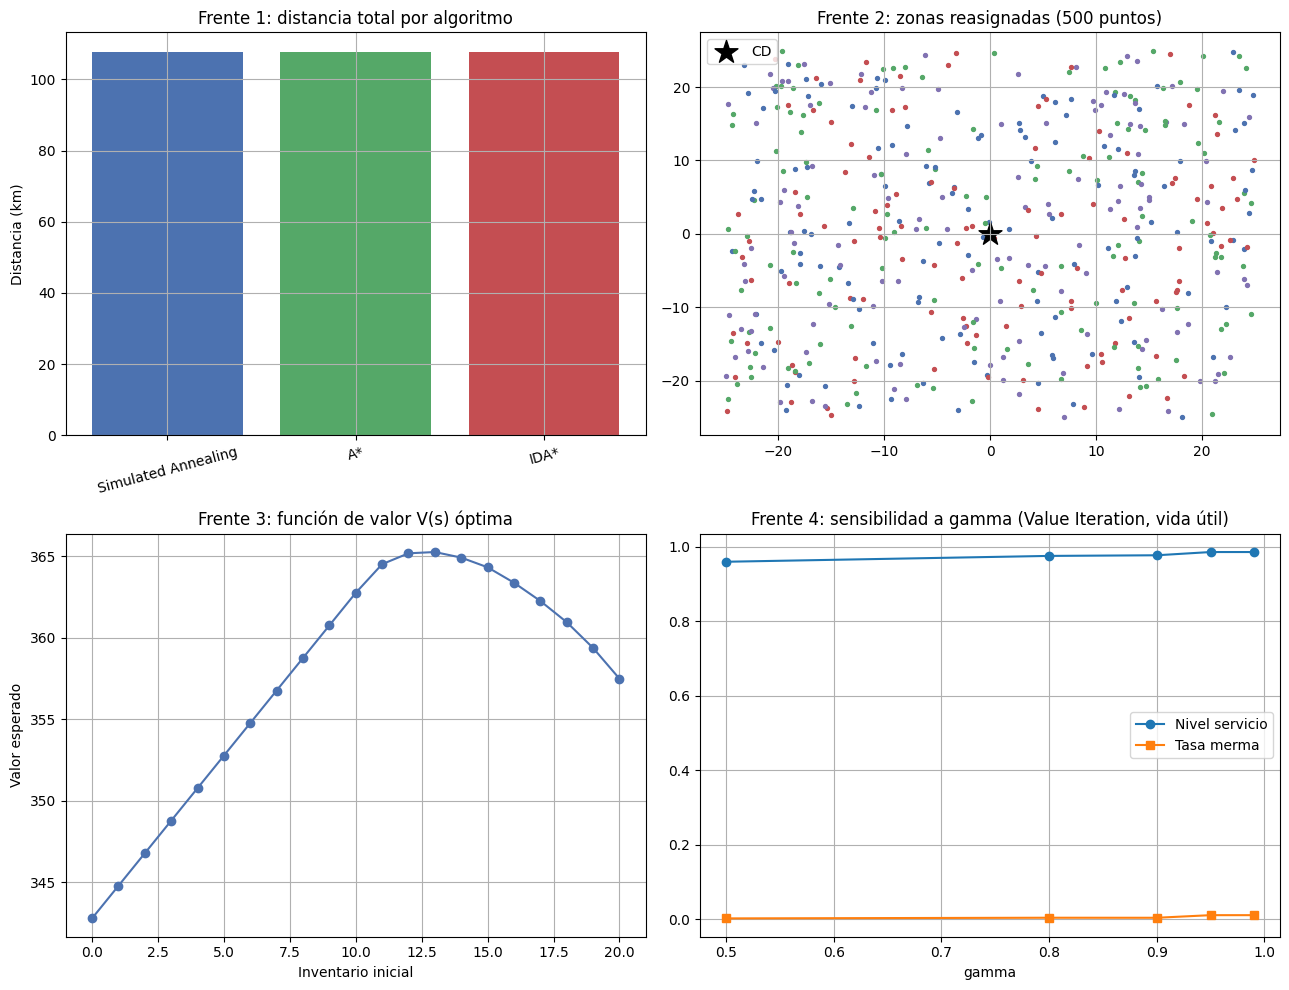

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(13, 10))

# Frente 1: comparación de distancia por algoritmo
axs[0, 0].bar(tabla_f1["Algoritmo"], tabla_f1["Distancia (km)"], color=["#4C72B0", "#55A868", "#C44E52"])
axs[0, 0].set_title("Frente 1: distancia total por algoritmo")
axs[0, 0].set_ylabel("Distancia (km)")
axs[0, 0].tick_params(axis="x", rotation=15)

# Frente 2: mapa de zonas asignadas sobre una instancia GRANDE (500 puntos) solo para la visualizacion
red_vis = generar_red_logistica(n_puntos=500, n_cuadrillas=4)   # red sintetica de 500 puntos
dist_vis = matriz_distancias(red_vis)
prob_vis = ProblemaZonas(red_vis, dist_vis, 4)
random.seed(SEED); np.random.seed(SEED)                          # reproducible
asig_vis = simulated_annealing(prob_vis, T0=500, alpha=0.999, Tmin=0.1, max_iter=300)  # max_iter moderado
colores = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]
for p, c in zip(prob_vis.puntos, asig_vis):
    axs[0, 1].scatter(red_vis["x"].iloc[p], red_vis["y"].iloc[p], color=colores[c % len(colores)], s=8)
axs[0, 1].scatter(red_vis["x"].iloc[0], red_vis["y"].iloc[0], color="black", marker="*", s=300, label="CD")
axs[0, 1].set_title("Frente 2: zonas reasignadas (500 puntos)")
axs[0, 1].legend()

# Frente 3: función de valor por nivel de inventario
estados = list(mdp_f3.S)
axs[1, 0].plot(estados, [V_f3[s] for s in estados], marker="o", color="#4C72B0")
axs[1, 0].set_title("Frente 3: función de valor V(s) óptima")
axs[1, 0].set_xlabel("Inventario inicial")
axs[1, 0].set_ylabel("Valor esperado")

# Frente 4: sensibilidad de nivel de servicio y merma a gamma (Value Iteration con vida util)
axs[1, 1].plot(tabla_gamma_vu_vi["gamma"], tabla_gamma_vu_vi["Nivel servicio"], marker="o", label="Nivel servicio")
axs[1, 1].plot(tabla_gamma_vu_vi["gamma"], tabla_gamma_vu_vi["Tasa merma"], marker="s", label="Tasa merma")
axs[1, 1].set_title("Frente 4: sensibilidad a gamma (Value Iteration, vida útil)")
axs[1, 1].set_xlabel("gamma")
axs[1, 1].legend()

plt.tight_layout()
plt.show()


### 6.2 Tablero de indicadores (KPI) frente a las metas OKR

In [19]:
def tablero_kpi():
    dist_actual = tabla_f2.loc[0, "Costo total red"]
    dist_optim = tabla_f2.loc[2, "Costo total red"]
    reduccion_dist = (1 - dist_optim / dist_actual) * 100

    r_opt = tabla_f3[tabla_f3["Politica"].str.contains("Policy")].iloc[0]
    r_heur = tabla_f3[tabla_f3["Politica"].str.contains("Heur")].iloc[0]

    filas = [
        ("DPV — Distancia por vehículo", f"{dist_actual:.0f}", f"{dist_optim:.0f}", f"-{reduccion_dist:.1f}%", "OKR1: -15%"),
        ("NS — Nivel de servicio", f"{r_heur['Nivel servicio']:.0%}", f"{r_opt['Nivel servicio']:.0%}", "↑", "OKR2: ≥91%"),
        ("TA — Tasa de agotados", f"{r_heur['Tasa agotados']:.0%}", f"{r_opt['Tasa agotados']:.0%}", "↓", "OKR2: ≤5%"),
        ("TMP — Tasa de merma", f"{r_heur['Tasa merma']:.0%}", f"{r_opt['Tasa merma']:.0%}", "↓", "OKR3: -35%"),
        ("Rentabilidad acumulada", f"{r_heur['Rentabilidad']:.0f}", f"{r_opt['Rentabilidad']:.0f}",
         f"+{(r_opt['Rentabilidad']/max(r_heur['Rentabilidad'],1)-1)*100:.0f}%", "OKR3: +12%"),
    ]
    return pd.DataFrame(filas, columns=["KPI", "Línea base", "Con solución", "Variación", "Meta OKR"])


tablero = tablero_kpi()
print("TABLERO DE INDICADORES — Solución integrada (4 frentes)")
print(tablero.to_string(index=False))


TABLERO DE INDICADORES — Solución integrada (4 frentes)
                         KPI Línea base Con solución Variación   Meta OKR
DPV — Distancia por vehículo       1830          908    -50.3% OKR1: -15%
      NS — Nivel de servicio        94%          90%         ↑ OKR2: ≥91%
       TA — Tasa de agotados         6%          10%         ↓  OKR2: ≤5%
         TMP — Tasa de merma        27%          14%         ↓ OKR3: -35%
      Rentabilidad acumulada        883         1068      +21% OKR3: +12%


---
# 7. Diseño experimental y validación estadística

Esta sección implementa el protocolo de la metodología (sección 3.4): construcción de escenarios etiquetados por dificultad, partición temporal train/validación/test, ejecución repetida con múltiples semillas y comparación estadística mediante pruebas no paramétricas (Wilcoxon y Friedman) con intervalos de confianza.

### 7.1 Construcción de escenarios y partición temporal

In [20]:
# construir_escenarios se define en el Frente 4 (subseccion 5.3 Robustez) y aqui se reutiliza.
def particion_temporal(serie, frac_train=0.6, frac_val=0.2):
    n = len(serie)
    i_tr = int(n * frac_train)
    i_val = int(n * (frac_train + frac_val))
    return serie[:i_tr], serie[i_tr:i_val], serie[i_val:]


escenarios_f3, resumen_escenarios = construir_escenarios(DEMANDA, punto=0)
serie_demo = DEMANDA[:, 0]
train_d, val_d, test_d = particion_temporal(serie_demo)

print("Escenarios construidos (Frente 3/4):")
print(resumen_escenarios.to_string(index=False))
print(f"\nParticion temporal: train={len(train_d)} | validacion={len(val_d)} | test={len(test_d)} dias")


Escenarios construidos (Frente 3/4):
   Escenario Dificultad  N dias  Demanda media  Desv. estandar
   ordinario       baja     140           53.9            11.5
alta_demanda      media      40           86.2            15.1
perturbacion       alta     180           66.5            24.3

Particion temporal: train=108 | validacion=36 | test=36 dias


### 7.2 Ejecución repetida con múltiples semillas

Cada método estocástico (Simulated Annealing) se ejecuta varias veces con semillas distintas para estimar media, desviación estándar e intervalo de confianza del 95% del desempeño, en lugar de depender de una única corrida.


In [21]:
def intervalo_confianza_95(muestras):
    m = np.mean(muestras)
    s = np.std(muestras, ddof=1) if len(muestras) > 1 else 0.0
    margen = 1.96 * s / math.sqrt(len(muestras)) if len(muestras) > 1 else 0.0
    return m, s, (m - margen, m + margen)


def repetir_sa_ruta(indices, dist, n_semillas=15):
    costos, tiempos = [], []
    for k in range(n_semillas):
        random.seed(SEED + k)
        np.random.seed(SEED + k)
        prob = ProblemaRuta(indices, dist)
        t0 = time.perf_counter()
        orden = simulated_annealing(prob)
        tiempos.append((time.perf_counter() - t0) * 1000)
        costos.append(prob.costo_ruta(orden))
    random.seed(SEED); np.random.seed(SEED)
    return np.array(costos), np.array(tiempos)


def experimento_multisemilla_f1(red, dist, n_exacto=7, n_semillas=15, semilla=SEED):
    rng = np.random.default_rng(semilla + 5)
    idx = list(rng.choice(range(1, len(red)), size=n_exacto, replace=False))

    costos_sa, tiempos_sa = repetir_sa_ruta(idx, dist, n_semillas)
    _, costo_a = a_estrella_ruta(idx, dist)
    _, costo_ida = ida_estrella_ruta(idx, dist)

    m_sa, s_sa, ic_sa = intervalo_confianza_95(costos_sa)
    tabla = pd.DataFrame([
        ("Simulated Annealing", round(m_sa, 2), round(s_sa, 2), f"[{ic_sa[0]:.1f}, {ic_sa[1]:.1f}]", round(costos_sa.min(), 2)),
        ("A* (exacto)", round(costo_a, 2), 0.0, "-", round(costo_a, 2)),
        ("IDA* (exacto)", round(costo_ida, 2), 0.0, "-", round(costo_ida, 2)),
    ], columns=["Algoritmo", "Media (km)", "Desv. est.", "IC 95%", "Mejor (km)"])
    return tabla, costos_sa, costo_a, idx


tabla_ms_f1, costos_sa_f1, costo_opt_f1, idx_ms_f1 = experimento_multisemilla_f1(red, DIST)
print("FRENTE 1 - Multi-semilla (15 corridas de SA vs optimo exacto)")
print(tabla_ms_f1.to_string(index=False))
brecha = (costos_sa_f1.mean() / costo_opt_f1 - 1) * 100
print(f"\nBrecha media de SA respecto al optimo (A*): {brecha:.2f}%")
print(f"SA encontro el optimo en {(np.abs(costos_sa_f1 - costo_opt_f1) < 1e-6).sum()}/{len(costos_sa_f1)} corridas")


FRENTE 1 - Multi-semilla (15 corridas de SA vs optimo exacto)
          Algoritmo  Media (km)  Desv. est.         IC 95%  Mejor (km)
Simulated Annealing      130.70        0.31 [130.5, 130.9]      130.54
        A* (exacto)      130.54        0.00              -      130.54
      IDA* (exacto)      130.54        0.00              -      130.54

Brecha media de SA respecto al optimo (A*): 0.12%
SA encontro el optimo en 12/15 corridas


In [22]:
def repetir_sa_zonas(red, dist, n_cuadrillas=4, n_semillas=10, config="lento"):
    params = {"lento": dict(T0=500, alpha=0.999, Tmin=0.1, max_iter=40000),
              "rapido": dict(T0=10, alpha=0.95, Tmin=0.1, max_iter=5000)}[config]
    costos = []
    prob = ProblemaZonas(red, dist, n_cuadrillas)
    for k in range(n_semillas):
        random.seed(SEED + k); np.random.seed(SEED + k)
        asign = simulated_annealing(prob, **params)
        costos.append(prob.costo_total(asign))
    random.seed(SEED); np.random.seed(SEED)
    return np.array(costos)


costos_lento = repetir_sa_zonas(red, DIST, config="lento", n_semillas=10)
costos_rapido = repetir_sa_zonas(red, DIST, config="rapido", n_semillas=10)

m_l, s_l, ic_l = intervalo_confianza_95(costos_lento)
m_r, s_r, ic_r = intervalo_confianza_95(costos_rapido)

tabla_ms_f2 = pd.DataFrame([
    ("SA enfriamiento rapido", round(m_r, 2), round(s_r, 2), f"[{ic_r[0]:.1f}, {ic_r[1]:.1f}]", round(costos_rapido.min(), 2)),
    ("SA T alta + enfriamiento lento", round(m_l, 2), round(s_l, 2), f"[{ic_l[0]:.1f}, {ic_l[1]:.1f}]", round(costos_lento.min(), 2)),
], columns=["Configuracion", "Media costo", "Desv. est.", "IC 95%", "Mejor"])

print("FRENTE 2 - Multi-semilla (10 corridas por configuracion)")
print(tabla_ms_f2.to_string(index=False))
print(f"\nEl enfriamiento lento mejora el costo medio en {(1 - m_l/m_r)*100:.1f}% frente al rapido.")


FRENTE 2 - Multi-semilla (10 corridas por configuracion)
                 Configuracion  Media costo  Desv. est.           IC 95%   Mejor
        SA enfriamiento rapido      1606.04       60.93 [1568.3, 1643.8] 1501.39
SA T alta + enfriamiento lento       918.34       17.30   [907.6, 929.1]  908.02

El enfriamiento lento mejora el costo medio en 42.8% frente al rapido.


### 7.3 Comparación estadística (Wilcoxon y Friedman)

Se contrasta si las diferencias de desempeño son estadísticamente significativas o atribuibles al azar. Wilcoxon compara dos configuraciones emparejadas (enfriamiento lento vs. rápido en el Frente 2); Friedman compara más de dos configuraciones de Simulated Annealing sobre las mismas semillas.

In [23]:
from scipy.stats import wilcoxon, friedmanchisquare


def comparar_configuraciones_sa(indices, dist, n_semillas=15):
    configs = {
        "alpha=0.99": dict(T0=100, alpha=0.99, Tmin=0.01),
        "alpha=0.995": dict(T0=100, alpha=0.995, Tmin=0.01),
        "alpha=0.999": dict(T0=100, alpha=0.999, Tmin=0.01),
    }
    resultados = {nombre: [] for nombre in configs}
    prob = ProblemaRuta(indices, dist)
    for k in range(n_semillas):
        for nombre, params in configs.items():
            random.seed(SEED + k); np.random.seed(SEED + k)
            orden = simulated_annealing(prob, **params)
            resultados[nombre].append(prob.costo_ruta(orden))
    random.seed(SEED); np.random.seed(SEED)
    return {k: np.array(v) for k, v in resultados.items()}


# Wilcoxon: enfriamiento lento vs rapido (Frente 2), muestras emparejadas por semilla
stat_w, p_w = wilcoxon(costos_lento, costos_rapido)
print("Prueba de Wilcoxon (Frente 2: lento vs rapido)")
print(f"  estadistico = {stat_w:.3f} | p-valor = {p_w:.5f}")
print(f"  {'Diferencia significativa (p<0.05)' if p_w < 0.05 else 'Sin diferencia significativa'}\n")

# Friedman: tres esquemas de enfriamiento de SA (Frente 1)
res_sa = comparar_configuraciones_sa(idx_ms_f1, DIST)
stat_f, p_f = friedmanchisquare(*res_sa.values())
print("Prueba de Friedman (Frente 1: tres factores de enfriamiento)")
print(f"  estadistico = {stat_f:.3f} | p-valor = {p_f:.5f}")
print(f"  {'Al menos una configuracion difiere (p<0.05)' if p_f < 0.05 else 'Sin diferencia significativa entre configuraciones'}")
tabla_friedman = pd.DataFrame([
    (nombre, round(v.mean(), 2), round(v.std(ddof=1), 2)) for nombre, v in res_sa.items()
], columns=["Config. enfriamiento", "Costo medio", "Desv. est."])
print()
print(tabla_friedman.to_string(index=False))


Prueba de Wilcoxon (Frente 2: lento vs rapido)
  estadistico = 0.000 | p-valor = 0.00195
  Diferencia significativa (p<0.05)



Prueba de Friedman (Frente 1: tres factores de enfriamiento)
  estadistico = 17.556 | p-valor = 0.00015
  Al menos una configuracion difiere (p<0.05)

Config. enfriamiento  Costo medio  Desv. est.
          alpha=0.99       132.00        1.95
         alpha=0.995       130.70        0.31
         alpha=0.999       130.54        0.00


---
# 8. Métricas operativas complementarias

Esta sección calcula las métricas que la metodología exige y que completan el tablero: consumo de combustible (Frente 1), Costo Promedio por Punto Abastecido (CPPA) y Porcentaje de Entregas Dentro de Ventana Horaria (PEDVH).

### 8.1 Consumo de combustible (Frente 1)

In [24]:
CONSUMO_L_POR_KM = 0.12          # coeficiente de consumo (litros/km) tipico de furgon urbano
PRECIO_COMBUSTIBLE = 16000.0     # COP por litro


def combustible_ruta(distancia_km, consumo=CONSUMO_L_POR_KM, precio=PRECIO_COMBUSTIBLE):
    litros = distancia_km * consumo
    return litros, litros * precio


# Comparacion: ruta optimizada (SA) vs ruta sin optimizar (orden aleatorio promedio)
prob_demo = ProblemaRuta(idx_grande_f1, DIST)
random.seed(SEED)
costos_aleatorios = [prob_demo.costo_ruta(prob_demo.estado_aleatorio()) for _ in range(30)]
dist_sin_opt = np.mean(costos_aleatorios)
orden_opt = simulated_annealing(prob_demo)
dist_opt = prob_demo.costo_ruta(orden_opt)

lit_sin, cop_sin = combustible_ruta(dist_sin_opt)
lit_opt, cop_opt = combustible_ruta(dist_opt)

tabla_combustible = pd.DataFrame([
    ("Sin optimizar (orden manual ~aleatorio)", round(dist_sin_opt, 1), round(lit_sin, 2), f"{cop_sin:,.0f}"),
    ("Optimizada (Simulated Annealing)", round(dist_opt, 1), round(lit_opt, 2), f"{cop_opt:,.0f}"),
], columns=["Recorrido", "Distancia (km)", "Combustible (L)", "Costo (COP)"])

print("FRENTE 1 - Consumo de combustible por vehiculo")
print(tabla_combustible.to_string(index=False))
ahorro = (1 - dist_opt / dist_sin_opt) * 100
print(f"\nAhorro de distancia y combustible por vehiculo: {ahorro:.1f}%")
print(f"Ahorro economico por vehiculo y jornada: {cop_sin - cop_opt:,.0f} COP")


FRENTE 1 - Consumo de combustible por vehiculo
                              Recorrido  Distancia (km)  Combustible (L) Costo (COP)
Sin optimizar (orden manual ~aleatorio)           598.8            71.86   1,149,706
       Optimizada (Simulated Annealing)           263.5            31.63     506,012

Ahorro de distancia y combustible por vehiculo: 56.0%
Ahorro economico por vehiculo y jornada: 643,693 COP


### 8.2 CPPA y PEDVH

El **CPPA** (Costo Promedio por Punto Abastecido) es el indicador primario de eficiencia económica del caso. El **PEDVH** (Porcentaje de Entregas Dentro de Ventana Horaria) mide el cumplimiento de las ventanas pactadas, simulando los tiempos de llegada a lo largo de la ruta optimizada frente a la ruta sin optimizar.

In [25]:
VELOCIDAD_KMH = 22.0       # velocidad media urbana en Bogota (km/h)
SERVICIO_MIN = 4.0         # minutos de atencion por punto
HORA_SALIDA = 4.0          # 4:00 a.m. salida del centro de distribucion
COSTO_FIJO_VEHICULO = 85000.0  # COP por jornada (conductor + desgaste)


def simular_ventanas(orden, red, dist, deposito=0):
    ruta = [deposito] + list(orden)
    t = HORA_SALIDA
    en_ventana = 0
    for i in range(1, len(ruta)):
        t += (dist[ruta[i - 1], ruta[i]] / VELOCIDAD_KMH) + (SERVICIO_MIN / 60.0)
        ini = red["ventana_ini"].iloc[ruta[i]]
        fin = red["ventana_fin"].iloc[ruta[i]]
        if ini <= t <= fin:
            en_ventana += 1
    return en_ventana / (len(ruta) - 1) * 100


def cppa(distancia_km, n_puntos):
    litros, costo_comb = combustible_ruta(distancia_km)
    costo_total = costo_comb + COSTO_FIJO_VEHICULO
    return costo_total / max(n_puntos, 1), costo_total


# Instancia de un vehiculo con carga realista (subconjunto cubrible dentro de las ventanas).
# Se compara el MISMO conjunto de puntos con orden optimizado vs orden manual (aleatorio).
idx_veh = idx_grande_f1[:12]
prob_veh = ProblemaRuta(idx_veh, DIST)
orden_veh_opt = simulated_annealing(prob_veh)
dist_veh_opt = prob_veh.costo_ruta(orden_veh_opt)
random.seed(SEED)
ordenes_manual = [prob_veh.estado_aleatorio() for _ in range(30)]
dist_veh_sin = np.mean([prob_veh.costo_ruta(o) for o in ordenes_manual])

pedvh_opt = simular_ventanas(orden_veh_opt, red, DIST)
pedvh_sin = np.mean([simular_ventanas(o, red, DIST) for o in ordenes_manual])

cppa_opt, _ = cppa(dist_veh_opt, len(idx_veh))
cppa_sin, _ = cppa(dist_veh_sin, len(idx_veh))

tabla_cppa_pedvh = pd.DataFrame([
    ("Sin optimizar (orden manual)", f"{cppa_sin:,.0f}", f"{pedvh_sin:.1f}%"),
    ("Optimizada (SA)", f"{cppa_opt:,.0f}", f"{pedvh_opt:.1f}%"),
], columns=["Recorrido", "CPPA (COP/punto)", "PEDVH"])

print("Indicadores operativos por vehiculo: CPPA y PEDVH")
print(f"(Instancia de {len(idx_veh)} puntos atendidos por un vehiculo)")
print(tabla_cppa_pedvh.to_string(index=False))
print(f"\nReduccion de CPPA: {(1 - cppa_opt/cppa_sin)*100:.1f}%  (meta OKR1-RC1: >=20%)")
print(f"Mejora de PEDVH: de {pedvh_sin:.1f}% a {pedvh_opt:.1f}%  (meta OKR2-RC1: >=93%)")


Indicadores operativos por vehiculo: CPPA y PEDVH
(Instancia de 12 puntos atendidos por un vehiculo)
                   Recorrido CPPA (COP/punto) PEDVH
Sin optimizar (orden manual)           50,734 17.2%
             Optimizada (SA)           26,731 50.0%

Reduccion de CPPA: 47.3%  (meta OKR1-RC1: >=20%)
Mejora de PEDVH: de 17.2% a 50.0%  (meta OKR2-RC1: >=93%)
